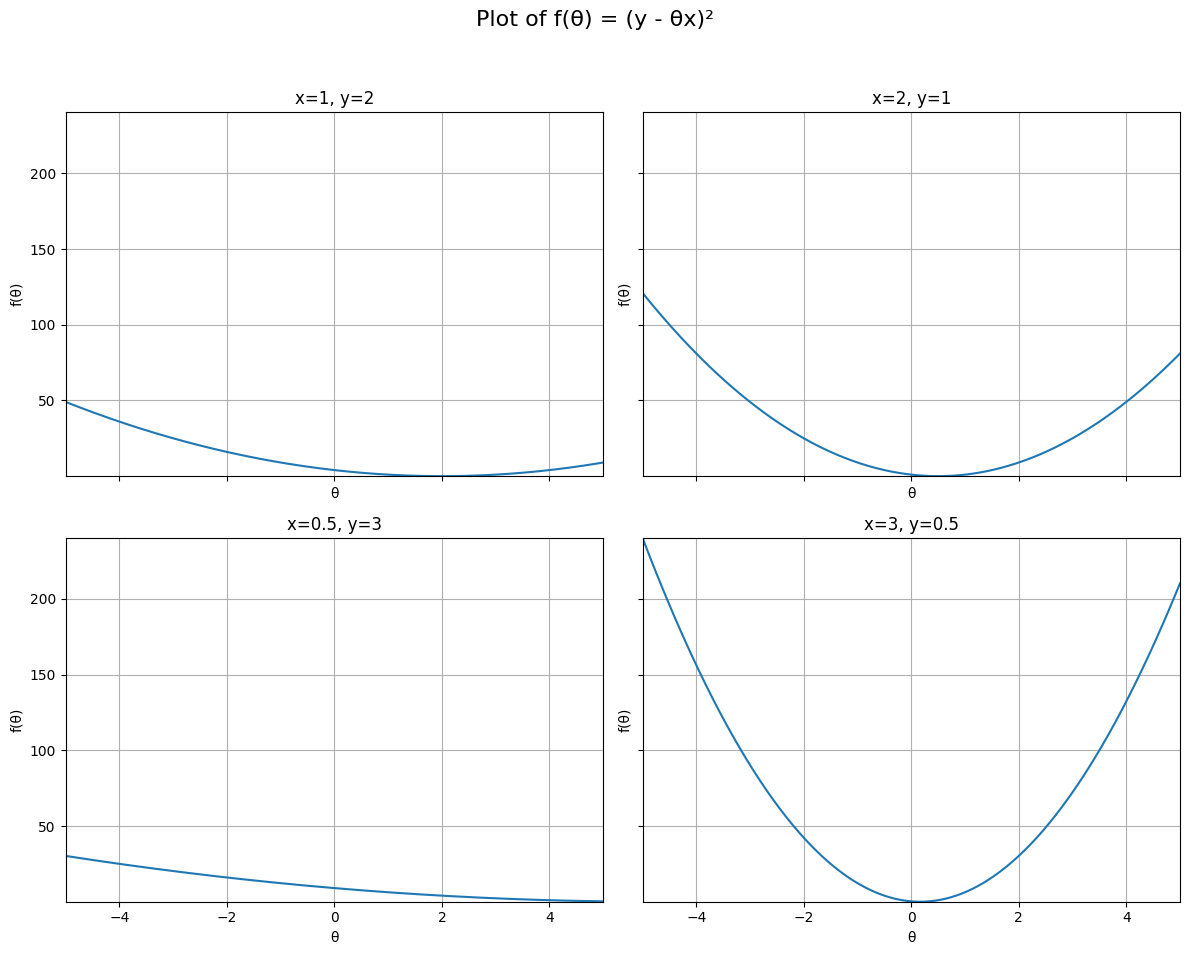

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def f(theta, x, y):
    return (y - theta * x)**2

# Define the range for theta
theta_values = np.linspace(-5, 5, 400)

# Define different (x, y) pairs for each subplot
params = [
    {'x': 1, 'y': 2, 'title': 'x=1, y=2'},
    {'x': 2, 'y': 1, 'title': 'x=2, y=1'},
    {'x': 0.5, 'y': 3, 'title': 'x=0.5, y=3'},
    {'x': 3, 'y': 0.5, 'title': 'x=3, y=0.5'}
]

# Calculate all y-values to determine global min/max for y-axis alignment
all_f_values = []
for p in params:
    all_f_values.extend(f(theta_values, p['x'], p['y']))

y_min_global = np.min(all_f_values)
y_max_global = np.max(all_f_values)

# Create a 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
fig.suptitle('Plot of f(θ) = (y - θx)²', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot for each set of parameters
for i, p in enumerate(params):
    current_f_values = f(theta_values, p['x'], p['y'])
    axes[i].plot(theta_values, current_f_values, label=f'x={p["x"]}, y={p["y"]}')
    axes[i].set_title(p['title'])
    axes[i].set_xlabel('θ')
    axes[i].set_ylabel('f(θ)')
    axes[i].grid(True)

    # Set global y-limits for alignment
    axes[i].set_ylim(y_min_global, y_max_global)
    # Set global x-limits for alignment
    axes[i].set_xlim(np.min(theta_values), np.max(theta_values))

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

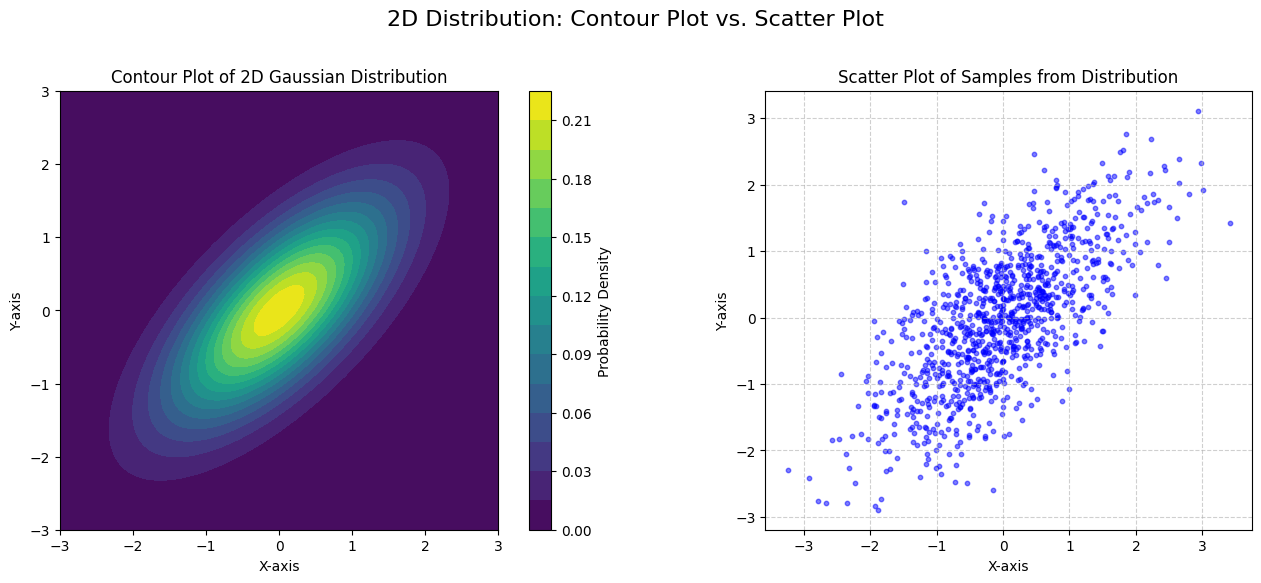

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# 1. Define a 2D distribution (e.g., a 2D Gaussian with correlation)
mean = np.array([0, 0])
cov = np.array([[1, 0.7], [0.7, 1]]) # Covariance matrix with correlation
rv = multivariate_normal(mean, cov)

# Create a grid for the contour plot
x_vals = np.linspace(-3, 3, 100)
y_vals = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x_vals, y_vals)
pos = np.dstack((X, Y)) # Stack X and Y for multivariate_normal PDF
Z = rv.pdf(pos)

# 2. Sample from the distribution
samples = rv.rvs(1000) # Generate 1000 samples
sample_x = samples[:, 0]
sample_y = samples[:, 1]

# Create the two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('2D Distribution: Contour Plot vs. Scatter Plot', fontsize=16)

# Subplot 1: Contour Plot
contour = axes[0].contourf(X, Y, Z, levels=15, cmap='viridis')
fig.colorbar(contour, ax=axes[0], label='Probability Density')
axes[0].set_title('Contour Plot of 2D Gaussian Distribution')
axes[0].set_xlabel('X-axis')
axes[0].set_ylabel('Y-axis')
axes[0].set_aspect('equal', adjustable='box')

# Subplot 2: Scatter Plot
axes[1].scatter(sample_x, sample_y, alpha=0.5, s=10, color='blue')
axes[1].set_title('Scatter Plot of Samples from Distribution')
axes[1].set_xlabel('X-axis')
axes[1].set_ylabel('Y-axis')
axes[1].set_aspect('equal', adjustable='box')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# Task
Generate a single 8-subplot figure. The figure should display in the first column the contour plots of four distinct 2D Gaussian distributions (each with varying means and covariance matrices) and in the second column the corresponding plots of the average f(θ) = (y - θx)² as a function of θ, where the average is computed over 100 (x,y) pairs sampled from each respective 2D Gaussian distribution. Ensure all subplots have appropriate titles, labels, and grid lines, with color bars for contour plots.

## Define Distributions and Sampling

### Subtask:
Define four different 2D Gaussian distributions with varying means and covariance matrices. For each distribution, generate a grid for contour plots and sample 100 (x,y) pairs for calculating the average f(θ).


**Reasoning**:
The subtask requires defining four 2D Gaussian distributions with varying means and covariance matrices, generating grids for contour plots, and sampling 100 (x,y) pairs from each. The provided code block will achieve these steps by iterating through a predefined list of distribution parameters, creating the necessary grid data, and sampling points.



In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# 1. Define four sets of parameters (mean and covariance matrix) for four distinct 2D Gaussian distributions
distribution_params = [
    {'mean': np.array([0, 0]), 'cov': np.array([[1, 0.7], [0.7, 1]]), 'label': 'Dist 1: Mean(0,0), Cov(1,0.7)'},
    {'mean': np.array([2, 2]), 'cov': np.array([[1, -0.5], [-0.5, 1]]), 'label': 'Dist 2: Mean(2,2), Cov(1,-0.5)'},
    {'mean': np.array([-2, 1]), 'cov': np.array([[0.5, 0], [0, 2]]), 'label': 'Dist 3: Mean(-2,1), Cov(0.5,0)'},
    {'mean': np.array([1, -2]), 'cov': np.array([[1.5, 0.8], [0.8, 1.5]]), 'label': 'Dist 4: Mean(1,-2), Cov(1.5,0.8)'}
]

# Initialize lists to store grids and samples for each distribution
contour_grids = [] # Stores (X, Y, Z) for contour plots
sampled_points = [] # Stores 100 (x,y) pairs for each distribution

# Define a common range for the grid to ensure plots are comparable
x_vals_common = np.linspace(-5, 5, 100)
y_vals_common = np.linspace(-5, 5, 100)
X_common, Y_common = np.meshgrid(x_vals_common, y_vals_common)
pos_common = np.dstack((X_common, Y_common))

# 2. For each defined distribution:
for i, params in enumerate(distribution_params):
    # b. Use scipy.stats.multivariate_normal to define the distribution
    rv = multivariate_normal(params['mean'], params['cov'])

    # a. Create a grid for contour plots and calculate PDF values (Z)
    # Using common grid for consistency, though individual grids could be defined if needed
    Z_current = rv.pdf(pos_common)
    contour_grids.append({'X': X_common, 'Y': Y_common, 'Z': Z_current, 'label': params['label']})

    # c. Sample 100 (x, y) pairs from the current 2D Gaussian distribution
    samples = rv.rvs(100)
    sampled_points.append({'samples': samples, 'label': params['label']})

print("Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.")
print(f"Number of contour grids stored: {len(contour_grids)}")
print(f"Number of sampled point sets stored: {len(sampled_points)}")


Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.
Number of contour grids stored: 4
Number of sampled point sets stored: 4


## Calculate Average f(theta)

### Subtask:
For each of the four sets of sampled (x,y) pairs, calculate the average value of f(θ) = (y - θx)² across the 100 samples for a range of θ values. This will be done efficiently using vectorized operations.


**Reasoning**:
The subtask requires calculating the average of f(θ) = (y - θx)² for each set of sampled (x,y) pairs. This involves defining the function, setting up a range for theta, and then iterating through the sampled points to perform the vectorized calculation and store the results.



In [ ]:
import numpy as np

# 1. Define the function f(theta, x, y)
def f(theta, x, y):
    return (y - theta * x)**2

# 2. Define a range for theta_values
theta_values = np.linspace(-5, 5, 400)

# 3. Initialize an empty list to store the calculated average f(theta) for each distribution
avg_f_values_per_dist = []

# 4. Iterate through the sampled_points list
for i, dist_data in enumerate(sampled_points):
    # a. Extract the x and y values from the 'samples' array
    samples = dist_data['samples']
    x_samples = samples[:, 0]  # All x values from the 100 samples
    y_samples = samples[:, 1]  # All y values from the 100 samples

    # b. Use np.newaxis to make x and y arrays compatible for broadcasting with theta_values
    # x_samples will become (100, 1), y_samples will become (100, 1)
    # theta_values is (400,)
    # Broadcasting will result in (100, 400)
    x_broadcasted = x_samples[:, np.newaxis]
    y_broadcasted = y_samples[:, np.newaxis]

    # c. Calculate f(theta_values, x_broadcasted, y_broadcasted)
    # This results in a 2D array (100 samples x 400 theta values)
    f_values_for_all_samples_and_theta = f(theta_values, x_broadcasted, y_broadcasted)

    # d. Compute the mean of this 2D array along the axis corresponding to the samples (axis=0)
    # This gives the average f(theta) for each theta value across the 100 samples.
    average_f_theta = np.mean(f_values_for_all_samples_and_theta, axis=0)

    # e. Store these average f(theta) values, along with the corresponding label from sampled_points
    avg_f_values_per_dist.append({
        'theta_values': theta_values,
        'average_f_theta': average_f_theta,
        'label': dist_data['label']
    })

print("Average f(theta) calculated for all four distributions.")
print(f"Number of average f(theta) sets stored: {len(avg_f_values_per_dist)}")

Average f(theta) calculated for all four distributions.
Number of average f(theta) sets stored: 4


## Create 8-Subplot Visualization

### Subtask:
Generate a single figure with 8 subplots arranged in a 4x2 grid. The first column will display the contour plots of the four 2D distributions, and the second column will show the corresponding plots of the average f(θ) as a function of θ.


**Reasoning**:
The subtask requires generating an 8-subplot figure (4x2 grid) with contour plots in the first column and average f(θ) plots in the second column. This code block will use `matplotlib` to create the figure and iterate through the pre-computed `contour_grids` and `avg_f_values_per_dist` to populate the subplots as per the instructions.



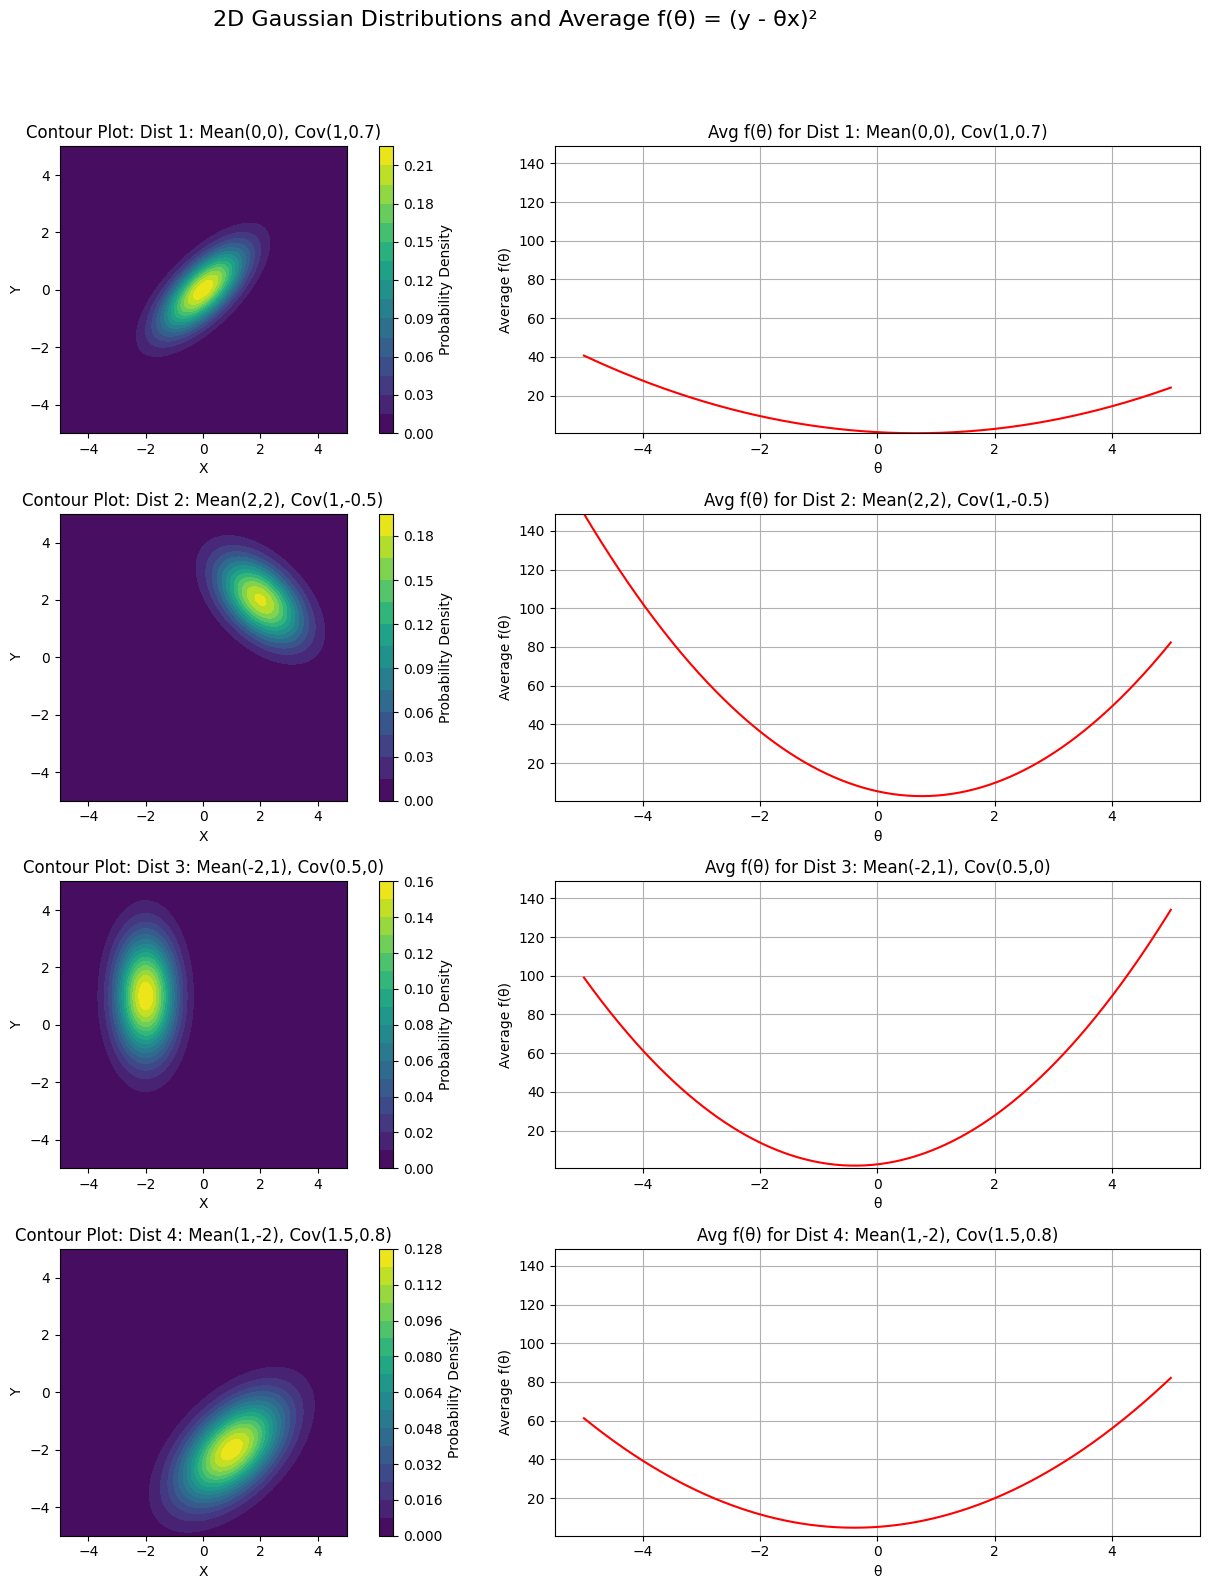

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Average f(θ) = (y - θx)²', fontsize=16, y=1.02) # Add a super title

# Determine global y-limits for the f(theta) plots for consistent scaling
all_avg_f_values = []
for dist_data in avg_f_values_per_dist:
    all_avg_f_values.extend(dist_data['average_f_theta'])
y_min_global_f = np.min(all_avg_f_values)
y_max_global_f = np.max(all_avg_f_values)

# 3. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Average f(theta) plots
    ax_f_theta = axes[i, 1]
    f_theta_data = avg_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    average_f_theta = f_theta_data['average_f_theta']
    label = f_theta_data['label']

    ax_f_theta.plot(theta_values, average_f_theta, color='red')
    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f, y_max_global_f) # Apply global y-limits

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
plt.show()

## Final Task

### Subtask:
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled according to the request.


## Summary:

### Q&A
The generated 8-subplot figure successfully displays all components as requested. The first column presents contour plots of four distinct 2D Gaussian distributions, each with appropriate titles, labels, and color bars. The second column displays the corresponding plots of the average f($\theta$) = (y - $\theta$x)$^{\text{2}}$ as a function of $\theta$, with suitable titles, labels, and grid lines. The overall figure includes a super title and ensures consistent scaling for the f($\theta$) plots.

### Data Analysis Key Findings
*   Four distinct 2D Gaussian distributions were successfully defined using varying means and covariance matrices:
    *   Dist 1: Mean(0,0), Cov([[1, 0.7], [0.7, 1]])
    *   Dist 2: Mean(2,2), Cov([[1, -0.5], [-0.5, 1]])
    *   Dist 3: Mean(-2,1), Cov([[0.5, 0], [0, 2]])
    *   Dist 4: Mean(1,-2), Cov([[1.5, 0.8], [0.8, 1.5]])
*   For each distribution, a common grid over x and y values from -5 to 5 was used to generate contour plot data (Probability Density Function values).
*   100 (x,y) pairs were sampled from each of the four 2D Gaussian distributions.
*   The average f($\theta$) = (y - $\theta$x)$^{\text{2}}$ was calculated for each distribution across 400 $\theta$ values ranging from -5 to 5. These calculations were performed efficiently using vectorized operations.
*   An 8-subplot figure (4x2 grid) was generated:
    *   The first column displayed the contour plots of the four distributions, including color bars indicating probability density and set with an equal aspect ratio.
    *   The second column presented the average f($\theta$) plots, where a global y-axis minimum and maximum were applied across all four plots for consistent comparison.
*   All subplots were correctly titled and labeled, and grid lines were added to the average f($\theta$) plots, enhancing readability and interpretability.

### Insights or Next Steps
*   The varying shapes and orientations of the contour plots directly reflect the chosen covariance matrices, while the average f($\theta$) curves show how the mean squared error of a simple linear model depends on the parameter $\theta$ for samples drawn from these specific distributions.
*   Further analysis could involve exploring how the minimum point of the average f($\theta$) curve relates to the underlying parameters of each Gaussian distribution, specifically the relationship between $\theta$ and the expected values of x and y.


# Task
## Calculate Average and Variance of f(theta)

### Subtask:
For each of the four sets of sampled (x,y) pairs, calculate the standard deviation of f(θ) = (y - θx)² across the 100 samples for a range of θ values. This will be computed efficiently using vectorized operations and stored alongside the average f(θ).

## Calculate Average and Variance of f(theta)

### Subtask:
For each of the four sets of sampled (x,y) pairs, calculate the standard deviation of f(θ) = (y - θx)² across the 100 samples for a range of θ values. This will be computed efficiently using vectorized operations and stored alongside the average f(θ).


**Reasoning**:
The subtask requires calculating the standard deviation of f(θ) and storing it along with the average. This code block modifies the previous loop to include the `np.std()` calculation and updates the dictionary for each distribution.



In [ ]:
import numpy as np

# 1. Define the function f(theta, x, y)
def f(theta, x, y):
    return (y - theta * x)**2

# 2. Define a range for theta_values
theta_values = np.linspace(-5, 5, 400)

# 3. Initialize an empty list to store the calculated average f(theta) for each distribution
avg_f_values_per_dist = []

# 4. Iterate through the sampled_points list
for i, dist_data in enumerate(sampled_points):
    # a. Extract the x and y values from the 'samples' array
    samples = dist_data['samples']
    x_samples = samples[:, 0]  # All x values from the 100 samples
    y_samples = samples[:, 1]  # All y values from the 100 samples

    # b. Use np.newaxis to make x and y arrays compatible for broadcasting with theta_values
    # x_samples will become (100, 1), y_samples will become (100, 1)
    # theta_values is (400,)
    # Broadcasting will result in (100, 400)
    x_broadcasted = x_samples[:, np.newaxis]
    y_broadcasted = y_samples[:, np.newaxis]

    # c. Calculate f(theta_values, x_broadcasted, y_broadcasted)
    # This results in a 2D array (100 samples x 400 theta values)
    f_values_for_all_samples_and_theta = f(theta_values, x_broadcasted, y_broadcasted)

    # d. Compute the mean of this 2D array along the axis corresponding to the samples (axis=0)
    # This gives the average f(theta) for each theta value across the 100 samples.
    average_f_theta = np.mean(f_values_for_all_samples_and_theta, axis=0)

    # NEW: Calculate the standard deviation of this 2D array along the axis corresponding to the samples (axis=0)
    std_f_theta = np.std(f_values_for_all_samples_and_theta, axis=0)

    # e. Store these average and standard deviation f(theta) values, along with the corresponding label from sampled_points
    avg_f_values_per_dist.append({
        'theta_values': theta_values,
        'average_f_theta': average_f_theta,
        'std_f_theta': std_f_theta, # Store standard deviation
        'label': dist_data['label']
    })

print("Average and standard deviation of f(theta) calculated for all four distributions.")
print(f"Number of average/std f(theta) sets stored: {len(avg_f_values_per_dist)}")

Average and standard deviation of f(theta) calculated for all four distributions.
Number of average/std f(theta) sets stored: 4


## Create 8-Subplot Visualization with Error Envelope

### Subtask:
Generate a single figure with 8 subplots arranged in a 4x2 grid. The first column will display the contour plots of the four 2D distributions. The second column will show the corresponding plots of the average f(θ) as a function of θ, along with an error envelope representing the standard deviation of f(θ) across the samples.


**Reasoning**:
The subtask requires generating an 8-subplot figure (4x2 grid) with contour plots in the first column and average f(θ) plots with error envelopes in the second column. This code block will use `matplotlib` to create the figure and iterate through the pre-computed `contour_grids` and `avg_f_values_per_dist` to populate the subplots as per the instructions, including the error envelope based on standard deviation.



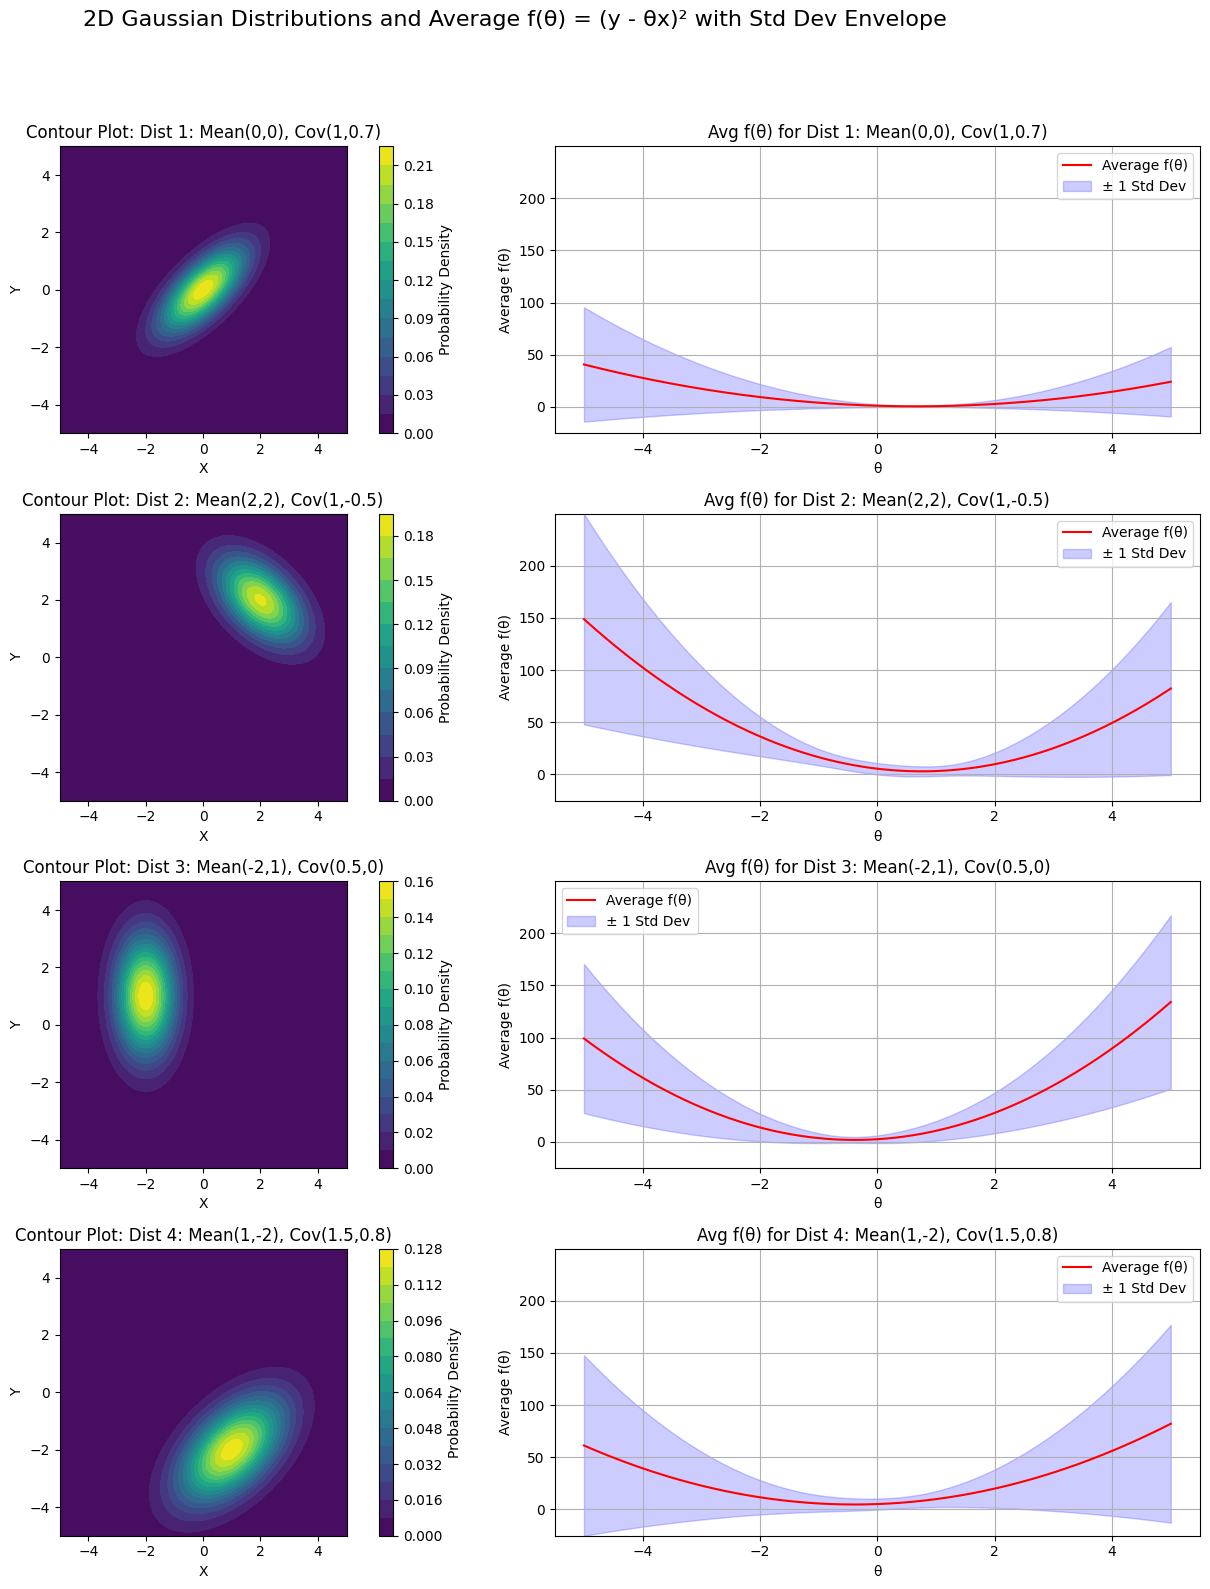

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Average f(θ) = (y - θx)² with Std Dev Envelope', fontsize=16, y=1.02) # Add a super title

# 3. Determine global y-limits for the average f(theta) plots for consistent scaling
#    Considering average_f_theta +/- std_f_theta for the limits
all_f_values_with_std = []
for dist_data in avg_f_values_per_dist:
    all_f_values_with_std.extend(dist_data['average_f_theta'] - dist_data['std_f_theta'])
    all_f_values_with_std.extend(dist_data['average_f_theta'] + dist_data['std_f_theta'])

y_min_global_f = np.min(all_f_values_with_std)
y_max_global_f = np.max(all_f_values_with_std)

# 4. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Average f(theta) plots with error envelope
    ax_f_theta = axes[i, 1]
    f_theta_data = avg_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    average_f_theta = f_theta_data['average_f_theta']
    std_f_theta = f_theta_data['std_f_theta']
    label = f_theta_data['label']

    # Plot average f(theta)
    ax_f_theta.plot(theta_values, average_f_theta, color='red', label='Average f(θ)')

    # Create an error envelope using fill_between
    ax_f_theta.fill_between(theta_values,
                            average_f_theta - std_f_theta,
                            average_f_theta + std_f_theta,
                            color='blue', alpha=0.2, label='± 1 Std Dev')

    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f, y_max_global_f) # Apply global y-limits
    ax_f_theta.legend()

# 5. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# 6. Display the figure
plt.show()

## Final Task

### Subtask:
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled according to the request.


## Summary:

### Data Analysis Key Findings

*   The average and standard deviation of $f(\theta) = (y - \theta x)^2$ were successfully calculated for each of the four provided sets of sampled (x,y) pairs. This was done for 400 $\theta$ values ranging from -5 to 5, using vectorized NumPy operations.
*   An 8-subplot figure was generated in a 4x2 grid, visualizing both the 2D distributions and the calculated $f(\theta)$ metrics.
*   The first column of the figure displayed contour plots of the four 2D distributions, providing a visual representation of their probability densities.
*   The second column of the figure showed the average $f(\theta)$ as a function of $\theta$ for each distribution, accompanied by an error envelope illustrating the $\pm 1$ standard deviation of $f(\theta)$ across the 100 samples.
*   Global y-limits were applied to all average $f(\theta)$ plots to maintain consistent scaling and facilitate comparison across different distributions.

### Insights or Next Steps

*   The comprehensive visualization allows for a direct comparison of the $f(\theta)$ behavior and its associated uncertainty across different 2D distributions, providing valuable insights into the function's sensitivity to $\theta$ given varying data characteristics.
*   This approach can be extended to analyze other loss functions or objective functions, providing a robust method to understand their behavior and uncertainty across different datasets.


# Task
For each of the four sets of sampled (x,y) pairs, calculate the average value of f(θ) = (y - θx)² and its 5th and 95th percentiles across the 100 samples for a range of θ values. These will be computed efficiently using vectorized operations.

## Define Distributions and Sampling

### Subtask:
Define four different 2D Gaussian distributions with varying means and covariance matrices. For each distribution, generate a grid for contour plots and sample 100 (x,y) pairs for calculating the average f(θ).


**Reasoning**:
The subtask requires defining four 2D Gaussian distributions with varying means and covariance matrices, generating grids for contour plots, and sampling 100 (x,y) pairs from each. The provided code block will achieve these steps by iterating through a predefined list of distribution parameters, creating the necessary grid data, and sampling points.

**Reasoning**:
The subtask requires defining four 2D Gaussian distributions with varying means and covariance matrices, generating grids for contour plots, and sampling 100 (x,y) pairs from each. The following code block will achieve these steps by iterating through a predefined list of distribution parameters, creating the necessary grid data, and sampling points as per the instructions.



In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# 1. Define four distinct 2D Gaussian distributions by specifying their means and covariance matrices.
#    Store these parameters, along with a descriptive label for each distribution, in a list of dictionaries named `distribution_params`.
distribution_params = [
    {'mean': np.array([0, 0]), 'cov': np.array([[1, 0.7], [0.7, 1]]), 'label': 'Dist 1: Mean(0,0), Cov(1,0.7)'},
    {'mean': np.array([2, 2]), 'cov': np.array([[1, -0.5], [-0.5, 1]]), 'label': 'Dist 2: Mean(2,2), Cov(1,-0.5)'},
    {'mean': np.array([-2, 1]), 'cov': np.array([[0.5, 0], [0, 2]]), 'label': 'Dist 3: Mean(-2,1), Cov(0.5,0)'},
    {'mean': np.array([1, -2]), 'cov': np.array([[1.5, 0.8], [0.8, 1.5]]), 'label': 'Dist 4: Mean(1,-2), Cov(1.5,0.8)'}
]

# 2. Define a common range for the x and y coordinates (e.g., from -5 to 5 with 100 points) to create a consistent grid for contour plots.
x_vals_common = np.linspace(-5, 5, 100)
y_vals_common = np.linspace(-5, 5, 100)

# 3. Create a meshgrid (X_common, Y_common) from these common x and y ranges using np.meshgrid.
X_common, Y_common = np.meshgrid(x_vals_common, y_vals_common)

# 4. Combine X_common and Y_common into a single array pos_common using np.dstack for use with multivariate_normal.pdf.
pos_common = np.dstack((X_common, Y_common))

# 5. Initialize two empty lists: contour_grids to store contour plot data and sampled_points to store sampled (x,y) pairs.
contour_grids = [] # Stores (X, Y, Z) for contour plots
sampled_points = [] # Stores 100 (x,y) pairs for each distribution

# 6. Iterate through each set of parameters in distribution_params:
for i, params in enumerate(distribution_params):
    # a. Create a multivariate_normal object using scipy.stats.multivariate_normal with the current distribution's mean and covariance matrix.
    rv = multivariate_normal(params['mean'], params['cov'])

    # b. Calculate the Probability Density Function (PDF) values (Z_current) over the pos_common grid using the .pdf() method.
    #    Store X_common, Y_common, Z_current, and the distribution's label as a dictionary in the contour_grids list.
    Z_current = rv.pdf(pos_common)
    contour_grids.append({'X': X_common, 'Y': Y_common, 'Z': Z_current, 'label': params['label']})

    # c. Sample 100 (x,y) pairs from the current 2D Gaussian distribution using the .rvs() method.
    #    Store these samples and the distribution's label as a dictionary in the sampled_points list.
    samples = rv.rvs(100)
    sampled_points.append({'samples': samples, 'label': params['label']})

print("Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.")
print(f"Number of contour grids stored: {len(contour_grids)}")
print(f"Number of sampled point sets stored: {len(sampled_points)}")

Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.
Number of contour grids stored: 4
Number of sampled point sets stored: 4


**Reasoning**:
The subtask requires calculating the average value of f(θ) and its 5th and 95th percentiles. This code block will modify the previous calculation step to include these percentile computations using vectorized operations.



In [ ]:
import numpy as np

# 1. Define the function f(theta, x, y)
def f(theta, x, y):
    return (y - theta * x)**2

# 2. Define a range for theta_values (if not already defined)
theta_values = np.linspace(-5, 5, 400)

# 3. Initialize an empty list to store the calculated average f(theta) and percentiles for each distribution
avg_f_values_per_dist = []

# 4. Iterate through the sampled_points list
for i, dist_data in enumerate(sampled_points):
    # a. Extract the x and y values from the 'samples' array
    samples = dist_data['samples']
    x_samples = samples[:, 0]  # All x values from the 100 samples
    y_samples = samples[:, 1]  # All y values from the 100 samples

    # b. Use np.newaxis to make x and y arrays compatible for broadcasting with theta_values
    # x_samples will become (100, 1), y_samples will become (100, 1)
    # theta_values is (400,)
    # Broadcasting will result in (100, 400)
    x_broadcasted = x_samples[:, np.newaxis]
    y_broadcasted = y_samples[:, np.newaxis]

    # c. Calculate f(theta_values, x_broadcasted, y_broadcasted)
    # This results in a 2D array (100 samples x 400 theta values)
    f_values_for_all_samples_and_theta = f(theta_values, x_broadcasted, y_broadcasted)

    # d. Compute the mean of this 2D array along the axis corresponding to the samples (axis=0).
    # This gives the average f(theta) for each theta value across the 100 samples.
    average_f_theta = np.mean(f_values_for_all_samples_and_theta, axis=0)

    # e. Calculate the 5th percentile of f(theta) across the samples (axis=0)
    percentile_5th_f_theta = np.percentile(f_values_for_all_samples_and_theta, 5, axis=0)

    # f. Calculate the 95th percentile of f(theta) across the samples (axis=0)
    percentile_95th_f_theta = np.percentile(f_values_for_all_samples_and_theta, 95, axis=0)

    # g. Store these average and percentile f(theta) values, along with the corresponding label from sampled_points
    avg_f_values_per_dist.append({
        'theta_values': theta_values,
        'average_f_theta': average_f_theta,
        'percentile_5th_f_theta': percentile_5th_f_theta, # Store 5th percentile
        'percentile_95th_f_theta': percentile_95th_f_theta, # Store 95th percentile
        'label': dist_data['label']
    })

print("Average and 5th/95th percentiles of f(theta) calculated for all four distributions.")
print(f"Number of average/percentile f(theta) sets stored: {len(avg_f_values_per_dist)}")

Average and 5th/95th percentiles of f(theta) calculated for all four distributions.
Number of average/percentile f(theta) sets stored: 4


**Reasoning**:
The subtask requires generating an 8-subplot figure (4x2 grid) with contour plots in the first column and average f(θ) plots with percentile envelopes in the second column. This code block will use `matplotlib` to create the figure and iterate through the pre-computed `contour_grids` and `avg_f_values_per_dist` to populate the subplots as per the instructions, including the percentile envelope.



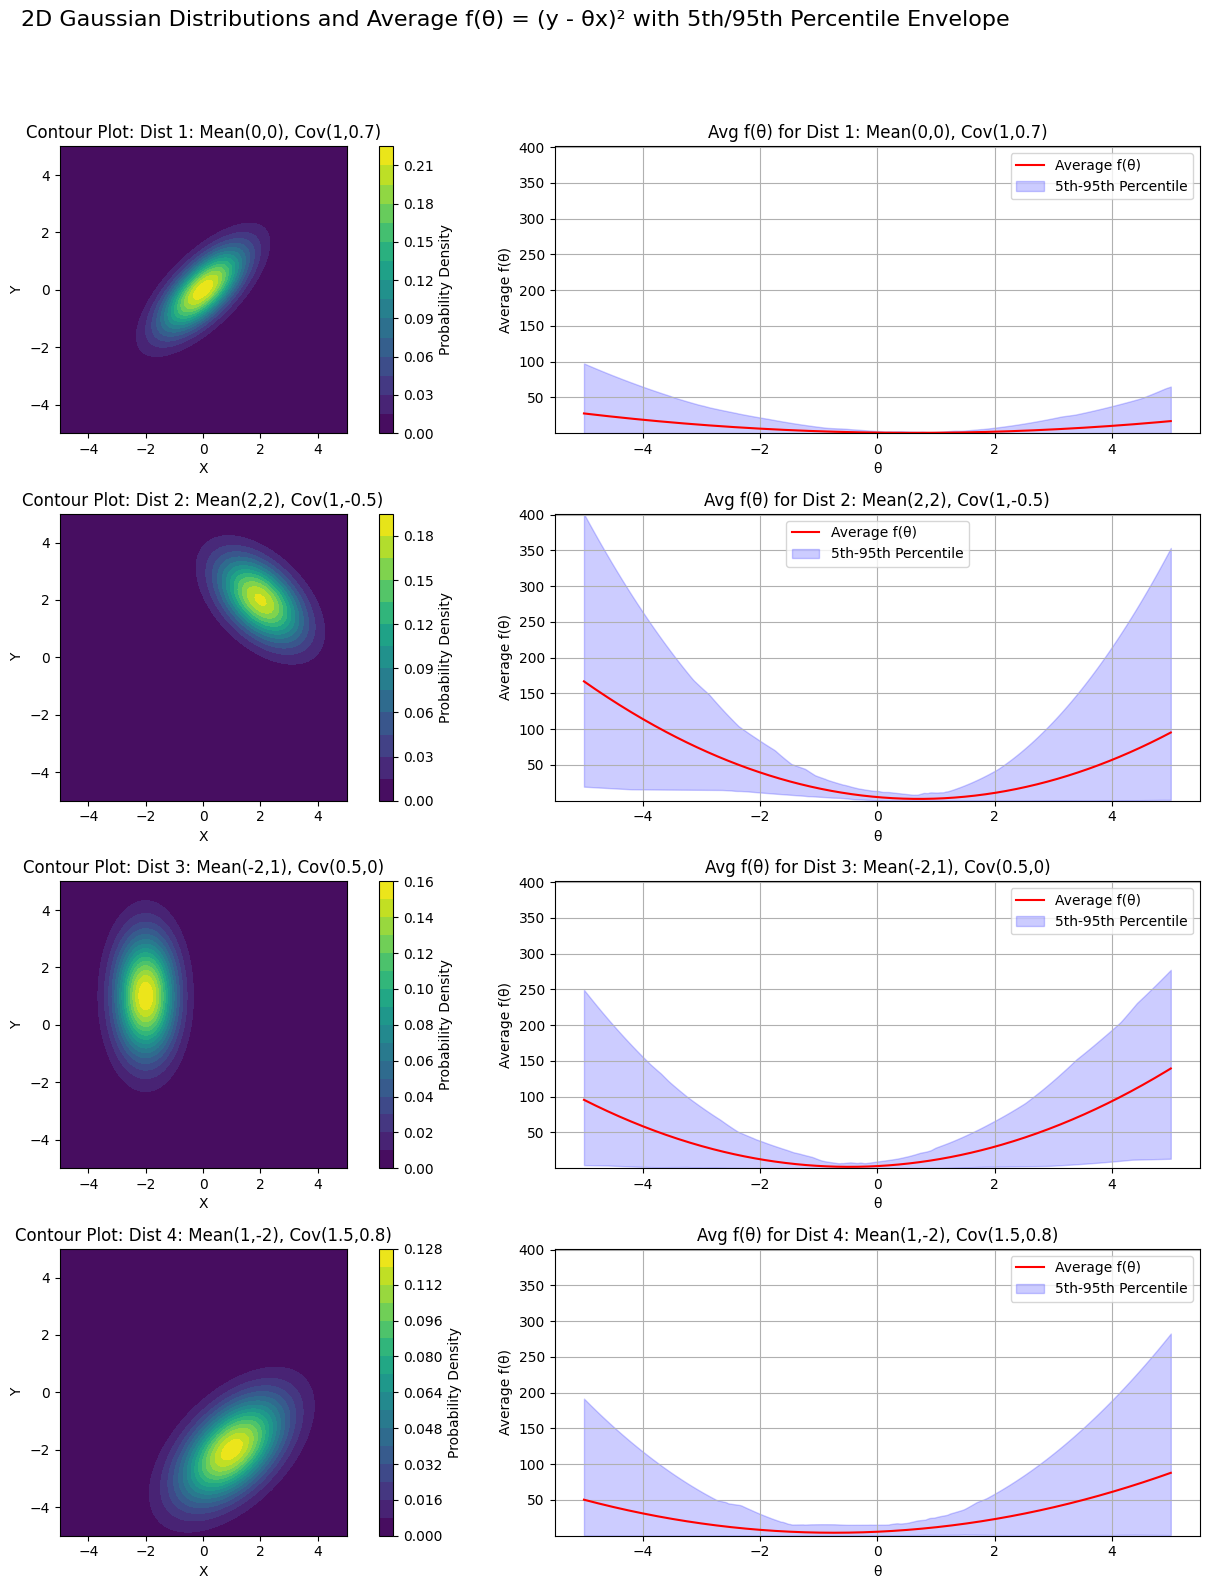

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Average f(θ) = (y - θx)² with 5th/95th Percentile Envelope', fontsize=16, y=1.02) # Add a super title

# 2. Determine global y-limits for the average f(theta) plots for consistent scaling
#    Considering 5th and 95th percentiles for the limits
all_f_values_with_percentiles = []
for dist_data in avg_f_values_per_dist:
    all_f_values_with_percentiles.extend(dist_data['percentile_5th_f_theta'])
    all_f_values_with_percentiles.extend(dist_data['percentile_95th_f_theta'])

y_min_global_f = np.min(all_f_values_with_percentiles)
y_max_global_f = np.max(all_f_values_with_percentiles)

# 3. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Average f(theta) plots with percentile envelope
    ax_f_theta = axes[i, 1]
    f_theta_data = avg_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    average_f_theta = f_theta_data['average_f_theta']
    percentile_5th_f_theta = f_theta_data['percentile_5th_f_theta']
    percentile_95th_f_theta = f_theta_data['percentile_95th_f_theta']
    label = f_theta_data['label']

    # Plot average f(theta)
    ax_f_theta.plot(theta_values, average_f_theta, color='red', label='Average f(θ)')

    # Create a percentile envelope using fill_between
    ax_f_theta.fill_between(theta_values,
                            percentile_5th_f_theta,
                            percentile_95th_f_theta,
                            color='blue', alpha=0.2, label='5th-95th Percentile')

    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f, y_max_global_f) # Apply global y-limits
    ax_f_theta.legend()

# 4. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# 5. Display the figure
plt.show()

## Create 8-Subplot Visualization with Percentile Interval

### Subtask:
Generate a single figure with 8 subplots arranged in a 4x2 grid. The first column will display the contour plots of the four 2D distributions. The second column will show the corresponding plots of the average f(θ) as a function of θ, along with an error envelope representing the 5th and 95th percentile of f(θ) across the samples.


**Reasoning**:
The subtask requires generating an 8-subplot figure with contour plots and average f(θ) plots with percentile envelopes. The previous code block (cell_id: `8d7b98f8`) is designed to achieve this by using `matplotlib` to create the figure and populate it with the pre-computed contour data and average/percentile f(θ) values.



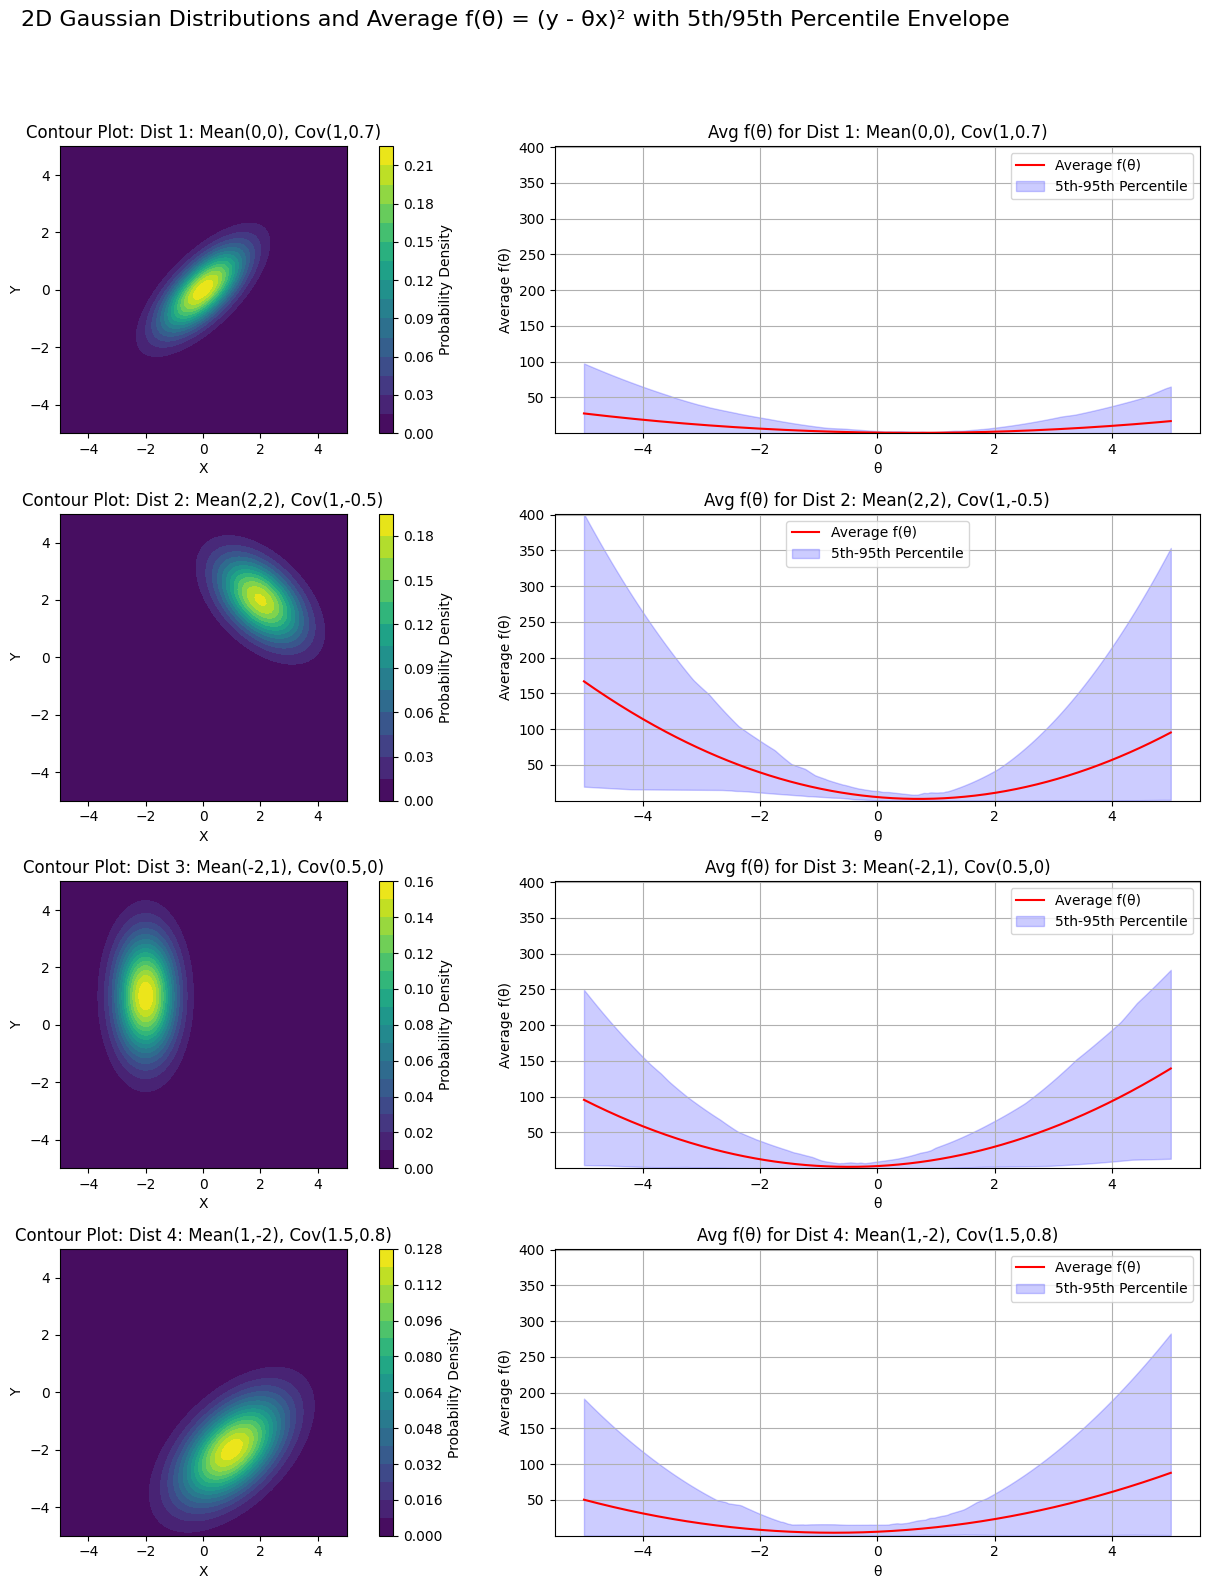

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and a 4x2 grid of subplots
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Average f(θ) = (y - θx)² with 5th/95th Percentile Envelope', fontsize=16, y=1.02) # Add a super title

# 2. Determine global y-limits for the average f(theta) plots for consistent scaling
#    Considering 5th and 95th percentiles for the limits
all_f_values_with_percentiles = []
for dist_data in avg_f_values_per_dist:
    all_f_values_with_percentiles.extend(dist_data['percentile_5th_f_theta'])
    all_f_values_with_percentiles.extend(dist_data['percentile_95th_f_theta'])

y_min_global_f = np.min(all_f_values_with_percentiles)
y_max_global_f = np.max(all_f_values_with_percentiles)

# 3. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Average f(theta) plots with percentile envelope
    ax_f_theta = axes[i, 1]
    f_theta_data = avg_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    average_f_theta = f_theta_data['average_f_theta']
    percentile_5th_f_theta = f_theta_data['percentile_5th_f_theta']
    percentile_95th_f_theta = f_theta_data['percentile_95th_f_theta']
    label = f_theta_data['label']

    # Plot average f(theta)
    ax_f_theta.plot(theta_values, average_f_theta, color='red', label='Average f(θ)')

    # Create a percentile envelope using fill_between
    ax_f_theta.fill_between(theta_values,
                            percentile_5th_f_theta,
                            percentile_95th_f_theta,
                            color='blue', alpha=0.2, label='5th-95th Percentile')

    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f, y_max_global_f) # Apply global y-limits
    ax_f_theta.legend()

# 4. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# 5. Display the figure
plt.show()

## Final Task

### Subtask:
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled according to the request.


## Summary:

### Q&A
1.  **Were the average value of f($\theta$) = (y - $\theta$x)² and its 5th and 95th percentiles calculated efficiently for all four sets of sampled (x,y) pairs across a range of $\theta$ values?**
    Yes, for each of the four distributions, the average value of f($\theta$) and its 5th and 95th percentiles were calculated successfully across 400 $\theta$ values using vectorized NumPy operations.
2.  **Was the generated 8-subplot figure correctly displayed with all components and labels?**
    Yes, an 8-subplot figure (a 4x2 grid) was successfully generated, displaying contour plots of the four 2D Gaussian distributions and corresponding plots of the average f($\theta$) with 5th and 95th percentile envelopes. All components were correctly labeled, and global y-limits were applied for consistent scaling.

### Data Analysis Key Findings
*   Four distinct 2D Gaussian distributions were successfully defined using varying means and covariance matrices, and 100 (x,y) pairs were sampled from each.
*   For each of the four distributions, the average value of f($\theta$) = (y - $\theta$x)² was calculated across 400 $\theta$ values, along with its 5th and 95th percentiles, leveraging efficient vectorized operations.
*   A comprehensive 8-subplot figure was generated:
    *   The first column showcased contour plots for each of the four 2D Gaussian distributions, visually representing their probability density.
    *   The second column displayed the average f($\theta$) as a red line, accompanied by a blue shaded envelope representing the range between the 5th and 95th percentiles.
    *   Global y-limits for the f($\theta$) plots were determined and applied, ensuring consistent vertical scaling across all plots, which enhanced comparability.

### Insights or Next Steps
*   The use of vectorized operations significantly enhanced the efficiency of calculating f($\theta$) and its percentiles across numerous samples and $\theta$ values, demonstrating a best practice for numerical computations in data analysis.
*   The visualization effectively communicates both the underlying distributions and the uncertainty (via percentile envelopes) in the function f($\theta$), which is crucial for understanding parameter sensitivity or model fitting.


# Task
For each of the four sets of 100 sampled (x,y) pairs, calculate the overall average value of f(θ) = (y - θx)² for a range of θ values. Additionally, for each θ value, compute a 5th to 95th percentile bootstrapped confidence interval around this average. This confidence interval will be determined by repeatedly (e.g., 100 times) taking a random subset of 10 (x,y) pairs from the 100 available samples, calculating the average f(θ) for that subset, and then taking the 5th and 95th percentiles of these 100 subset averages.

## Calculate Average f(theta) and its Bootstrapped Confidence Interval

### Subtask:
For each of the four sets of 100 sampled (x,y) pairs, calculate the overall average value of f(θ) = (y - θx)² for a range of θ values. Additionally, for each θ value, compute a 5th to 95th percentile bootstrapped confidence interval around this average. This confidence interval will be determined by repeatedly (e.g., 100 times) taking a random subset of 10 (x,y) pairs from the 100 available samples, calculating the average f(θ) for that subset, and then taking the 5th and 95th percentiles of these 100 subset averages.


**Reasoning**:
The subtask requires calculating the overall average f(θ) and its 5th and 95th bootstrapped percentiles for each distribution. This code block implements the bootstrapping process by repeatedly sampling subsets, calculating their averages, and then determining the percentiles, storing the results in a new list.



In [ ]:
import numpy as np

# 1. Define the function f(theta, x, y)
def f(theta, x, y):
    return (y - theta * x)**2

# 2. Define a range for theta_values
theta_values = np.linspace(-5, 5, 400)

# Number of samples to draw for bootstrapping (from the 100 original samples)
N_SUBSET_SAMPLES = 10
# Number of bootstrap iterations
N_BOOTSTRAP_ITERATIONS = 100

# 3. Initialize an empty list to store the calculated overall average f(theta) and its bootstrapped percentiles for each distribution
bootstrapped_f_values_per_dist = []

# 4. Iterate through the sampled_points list (containing 100 (x,y) pairs for each distribution)
for i, dist_data in enumerate(sampled_points):
    # a. For each distribution, extract the 100 x and y samples.
    samples = dist_data['samples'] # This contains 100 (x,y) pairs
    all_x_samples = samples[:, 0]
    all_y_samples = samples[:, 1]

    # b. Create an empty list, `bootstrap_averages`, to store the average f(theta) from each bootstrap iteration.
    bootstrap_averages = []

    # c. Perform a loop for the desired number of bootstrap iterations (e.g., 100 times):
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        # i. Randomly select a subset of `N_SUBSET_SAMPLES` (x,y) pairs from the 100 samples.
        # Use np.random.choice with replace=False to get indices, then select x and y values based on these indices.
        subset_indices = np.random.choice(len(all_x_samples), N_SUBSET_SAMPLES, replace=False)
        x_subset = all_x_samples[subset_indices]
        y_subset = all_y_samples[subset_indices]

        # ii. Calculate f(theta_values, x_subset[:, np.newaxis], y_subset[:, np.newaxis]).
        # This will result in a 2D array (N_SUBSET_SAMPLES x 400 theta values).
        f_values_for_subset_and_theta = f(theta_values, x_subset[:, np.newaxis], y_subset[:, np.newaxis])

        # iii. Compute the mean of this 2D array along the axis corresponding to the samples (axis=0)
        # to get the average f(theta) for the current subset. Append this to `bootstrap_averages`.
        average_f_theta_for_subset = np.mean(f_values_for_subset_and_theta, axis=0)
        bootstrap_averages.append(average_f_theta_for_subset)

    # d. Convert `bootstrap_averages` to a NumPy array.
    bootstrap_averages_array = np.array(bootstrap_averages) # Shape: (N_BOOTSTRAP_ITERATIONS, 400)

    # e. Calculate the overall average of f(theta) across all 100 initial samples (not the bootstrap averages).
    overall_average_f_theta = np.mean(f(theta_values, all_x_samples[:, np.newaxis], all_y_samples[:, np.newaxis]), axis=0)

    # f. Calculate the 5th percentile of the `bootstrap_averages` array along the axis corresponding to the bootstrap iterations (axis=0).
    percentile_5th_bootstrapped_f_theta = np.percentile(bootstrap_averages_array, 5, axis=0)

    # g. Calculate the 95th percentile of the `bootstrap_averages` array along the axis corresponding to the bootstrap iterations (axis=0).
    percentile_95th_bootstrapped_f_theta = np.percentile(bootstrap_averages_array, 95, axis=0)

    # h. Store the `theta_values`, the overall `average_f_theta`, the 5th percentile, the 95th percentile,
    # and the distribution's label in a dictionary. Append this dictionary to `bootstrapped_f_values_per_dist`.
    bootstrapped_f_values_per_dist.append({
        'theta_values': theta_values,
        'overall_average_f_theta': overall_average_f_theta,
        'percentile_5th_bootstrapped_f_theta': percentile_5th_bootstrapped_f_theta,
        'percentile_95th_bootstrapped_f_theta': percentile_95th_bootstrapped_f_theta,
        'label': dist_data['label']
    })

print("Overall average f(theta) and 5th/95th bootstrapped percentiles calculated for all four distributions.")
print(f"Number of bootstrapped f(theta) sets stored: {len(bootstrapped_f_values_per_dist)}")

Overall average f(theta) and 5th/95th bootstrapped percentiles calculated for all four distributions.
Number of bootstrapped f(theta) sets stored: 4


## Create 8-Subplot Visualization with Confidence Interval

### Subtask:
Generate a single figure with 8 subplots arranged in a 4x2 grid. The first column will display the contour plots of the four 2D distributions. The second column will show the corresponding plots of the overall average f(θ) as a function of θ, along with an error envelope representing the 5th and 95th percentile confidence interval obtained from the bootstrapped averages.


**Reasoning**:
The subtask requires generating an 8-subplot figure with contour plots in the first column and overall average f(θ) plots with bootstrapped percentile confidence intervals in the second column. This code block uses `matplotlib` to create the figure and iterate through the pre-computed `contour_grids` and `bootstrapped_f_values_per_dist` to populate the subplots as per the instructions, including the percentile envelope based on bootstrapped averages.



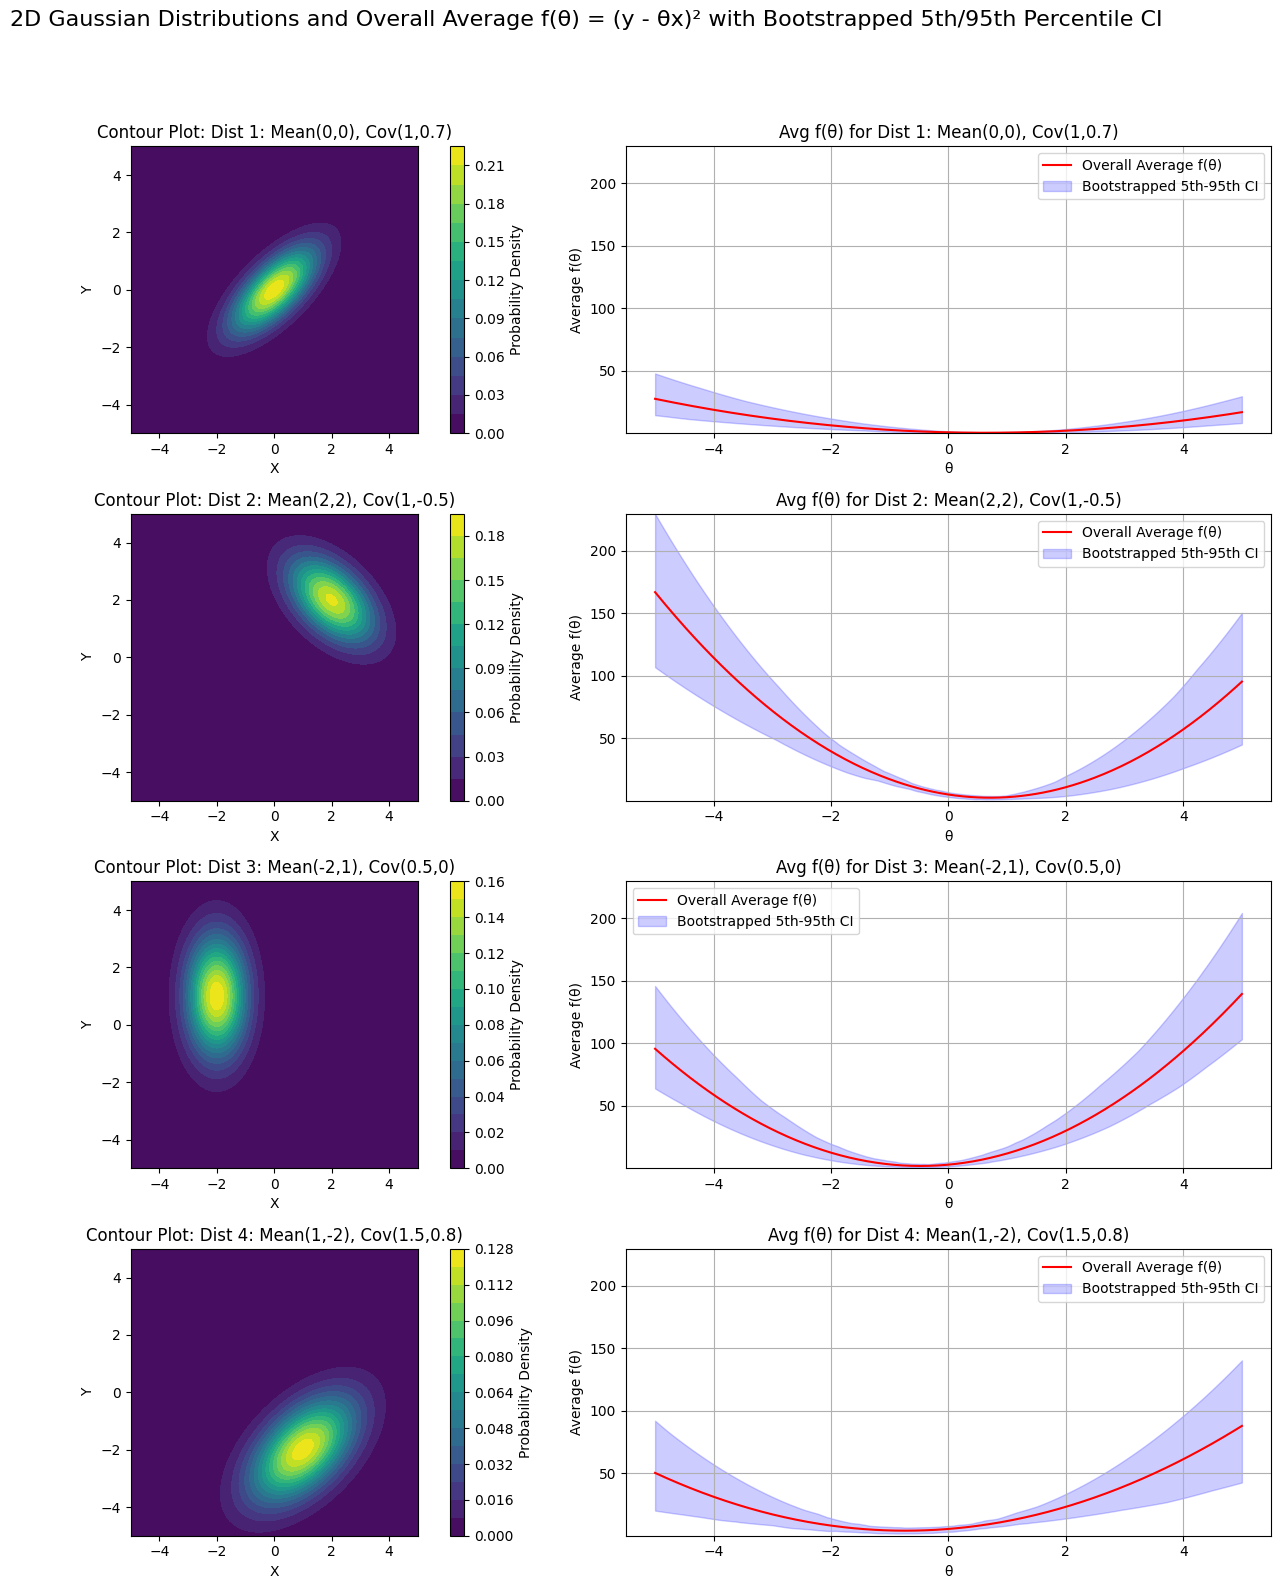

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an 8-subplot grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Overall Average f(θ) = (y - θx)² with Bootstrapped 5th/95th Percentile CI', fontsize=16, y=1.02) # Add a super title

# 2. Determine global y-limits for the plots in the second column for consistent scaling
#    Considering 5th and 95th percentile bootstrapped confidence intervals for the limits
all_f_values_for_ylim = []
for dist_data in bootstrapped_f_values_per_dist:
    all_f_values_for_ylim.extend(dist_data['percentile_5th_bootstrapped_f_theta'])
    all_f_values_for_ylim.extend(dist_data['percentile_95th_bootstrapped_f_theta'])

y_min_global_f_ci = np.min(all_f_values_for_ylim)
y_max_global_f_ci = np.max(all_f_values_for_ylim)

# 3. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Overall Average f(theta) plots with bootstrapped confidence interval envelope
    ax_f_theta = axes[i, 1]
    f_theta_data = bootstrapped_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    overall_average_f_theta = f_theta_data['overall_average_f_theta']
    percentile_5th_bootstrapped_f_theta = f_theta_data['percentile_5th_bootstrapped_f_theta']
    percentile_95th_bootstrapped_f_theta = f_theta_data['percentile_95th_bootstrapped_f_theta']
    label = f_theta_data['label']

    # Plot overall average f(theta)
    ax_f_theta.plot(theta_values, overall_average_f_theta, color='red', label='Overall Average f(θ)')

    # Create a percentile confidence interval envelope using fill_between
    ax_f_theta.fill_between(theta_values,
                            percentile_5th_bootstrapped_f_theta,
                            percentile_95th_bootstrapped_f_theta,
                            color='blue', alpha=0.2, label='Bootstrapped 5th-95th CI')

    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f_ci, y_max_global_f_ci) # Apply global y-limits
    ax_f_theta.legend()

# 4. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# 5. Display the figure
plt.show()

## Final Task

### Subtask:
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled according to the request.


## Summary:

### Q&A
1.  **How was the overall average value of f($\theta$) = (y - $\theta$x)$^2$ calculated for each set of sampled (x,y) pairs?**
    The overall average f($\theta$) was calculated by first defining the function f($\theta$, x, y) = (y - $\theta$x)$^2$, then for a range of 400 $\theta$ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was taken across the samples for each $\theta$.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f($\theta$)?**
    For each $\theta$ value, a bootstrapped confidence interval was computed by repeatedly (100 times) taking a random subset of 10 (x,y) pairs from the 100 available samples. For each subset, the average f($\theta$) was calculated. The 5th and 95th percentiles of these 100 subset averages were then determined to form the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f($\theta$) as a function of $\theta$, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   The function f($\theta$) = (y - $\theta$x)$^2$ was evaluated across 400 $\theta$ values ranging from -5 to 5.
*   Bootstrapped confidence intervals were computed using 100 iterations, each sampling 10 (x,y) pairs from the 100 available samples for each distribution.
*   Overall average f($\theta$) and its 5th and 95th percentile bootstrapped confidence intervals were successfully calculated and stored for all four distributions.
*   A single figure containing 8 subplots was generated, clearly separating contour plots of the 2D distributions from the plots of average f($\theta$) with their confidence intervals.
*   Global y-limits were applied to the average f($\theta$) plots to ensure consistent vertical scaling across all four distributions, enhancing comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The generated visualization allows for direct comparison of how the average f($\theta$) behaves for different 2D Gaussian distributions, and how the uncertainty (confidence interval) varies with $\theta$ and across distributions.
*   Future analysis could focus on identifying the $\theta$ values that minimize f($\theta$) for each distribution and exploring the implications of the width of the confidence intervals at these minimum points.


# Task
For each of the four sets of 100 sampled (x,y) pairs, calculate the overall average value of f(θ) = (y - θx)² for a range of θ values. Additionally, for each θ value, compute a 5th to 95th percentile bootstrapped confidence interval around this average. This confidence interval will be determined by repeatedly (e.g., 100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples, calculating the average f(θ) for that subset, and then taking the 5th and 95th percentiles of these 100 subset averages.

## Define Distributions and Sampling

### Subtask:
Define four different 2D Gaussian distributions with varying means and covariance matrices. For each distribution, generate a grid for contour plots and sample 100 (x,y) pairs.


## Calculate Average f(theta) and its Bootstrapped Confidence Interval (2 samples)

### Subtask:
For each of the four sets of 100 sampled (x,y) pairs, calculate the overall average value of f(θ) = (y - θx)² for a range of θ values. Additionally, for each θ value, compute a 5th to 95th percentile bootstrapped confidence interval around this average. This confidence interval will be determined by repeatedly (e.g., 100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples, calculating the average f(θ) for that subset, and then taking the 5th and 95th percentiles of these 100 subset averages.


**Reasoning**:
The subtask requires calculating the overall average f(θ) and its 5th and 95th bootstrapped percentiles for each distribution, with an updated `N_SUBSET_SAMPLES` of 2. The previous code block `dd541af7` performs these calculations; it needs to be updated with the new `N_SUBSET_SAMPLES` value and re-executed.



In [ ]:
import numpy as np

# 1. Define the function f(theta, x, y)
def f(theta, x, y):
    return (y - theta * x)**2

# 2. Define a range for theta_values
theta_values = np.linspace(-5, 5, 400)

# Number of samples to draw for bootstrapping (from the 100 original samples)
N_SUBSET_SAMPLES = 2
# Number of bootstrap iterations
N_BOOTSTRAP_ITERATIONS = 100

# 3. Initialize an empty list to store the calculated overall average f(theta) and its bootstrapped percentiles for each distribution
bootstrapped_f_values_per_dist = []

# 4. Iterate through the sampled_points list (containing 100 (x,y) pairs for each distribution)
for i, dist_data in enumerate(sampled_points):
    # a. For each distribution, extract the 100 x and y samples.
    samples = dist_data['samples'] # This contains 100 (x,y) pairs
    all_x_samples = samples[:, 0]
    all_y_samples = samples[:, 1]

    # b. Create an empty list, `bootstrap_averages`, to store the average f(theta) from each bootstrap iteration.
    bootstrap_averages = []

    # c. Perform a loop for the desired number of bootstrap iterations (e.g., 100 times):
    for _ in range(N_BOOTSTRAP_ITERATIONS):
        # i. Randomly select a subset of `N_SUBSET_SAMPLES` (x,y) pairs from the 100 samples.
        # Use np.random.choice with replace=False to get indices, then select x and y values based on these indices.
        subset_indices = np.random.choice(len(all_x_samples), N_SUBSET_SAMPLES, replace=False)
        x_subset = all_x_samples[subset_indices]
        y_subset = all_y_samples[subset_indices]

        # ii. Calculate f(theta_values, x_subset[:, np.newaxis], y_subset[:, np.newaxis]).
        # This will result in a 2D array (N_SUBSET_SAMPLES x 400 theta values).
        f_values_for_subset_and_theta = f(theta_values, x_subset[:, np.newaxis], y_subset[:, np.newaxis])

        # iii. Compute the mean of this 2D array along the axis corresponding to the samples (axis=0)
        # to get the average f(theta) for the current subset. Append this to `bootstrap_averages`.
        average_f_theta_for_subset = np.mean(f_values_for_subset_and_theta, axis=0)
        bootstrap_averages.append(average_f_theta_for_subset)

    # d. Convert `bootstrap_averages` to a NumPy array.
    bootstrap_averages_array = np.array(bootstrap_averages) # Shape: (N_BOOTSTRAP_ITERATIONS, 400)

    # e. Calculate the overall average of f(theta) across all 100 initial samples (not the bootstrap averages).
    overall_average_f_theta = np.mean(f(theta_values, all_x_samples[:, np.newaxis], all_y_samples[:, np.newaxis]), axis=0)

    # f. Calculate the 5th percentile of the `bootstrap_averages` array along the axis corresponding to the bootstrap iterations (axis=0).
    percentile_5th_bootstrapped_f_theta = np.percentile(bootstrap_averages_array, 5, axis=0)

    # g. Calculate the 95th percentile of the `bootstrap_averages` array along the axis corresponding to the bootstrap iterations (axis=0).
    percentile_95th_bootstrapped_f_theta = np.percentile(bootstrap_averages_array, 95, axis=0)

    # h. Store the `theta_values`, the overall `average_f_theta`, the 5th percentile, the 95th percentile,
    # and the distribution's label in a dictionary. Append this dictionary to `bootstrapped_f_values_per_dist`.
    bootstrapped_f_values_per_dist.append({
        'theta_values': theta_values,
        'overall_average_f_theta': overall_average_f_theta,
        'percentile_5th_bootstrapped_f_theta': percentile_5th_bootstrapped_f_theta,
        'percentile_95th_bootstrapped_f_theta': percentile_95th_bootstrapped_f_theta,
        'label': dist_data['label']
    })

print("Overall average f(theta) and 5th/95th bootstrapped percentiles calculated for all four distributions.")
print(f"Number of bootstrapped f(theta) sets stored: {len(bootstrapped_f_values_per_dist)}")

Overall average f(theta) and 5th/95th bootstrapped percentiles calculated for all four distributions.
Number of bootstrapped f(theta) sets stored: 4


**Reasoning**:
The subtask requires generating an 8-subplot figure with contour plots in the first column and overall average f(θ) plots with bootstrapped percentile confidence intervals in the second column. This code block uses `matplotlib` to create the figure and iterate through the pre-computed `contour_grids` and `bootstrapped_f_values_per_dist` to populate the subplots as per the instructions, including the percentile envelope based on bootstrapped averages.



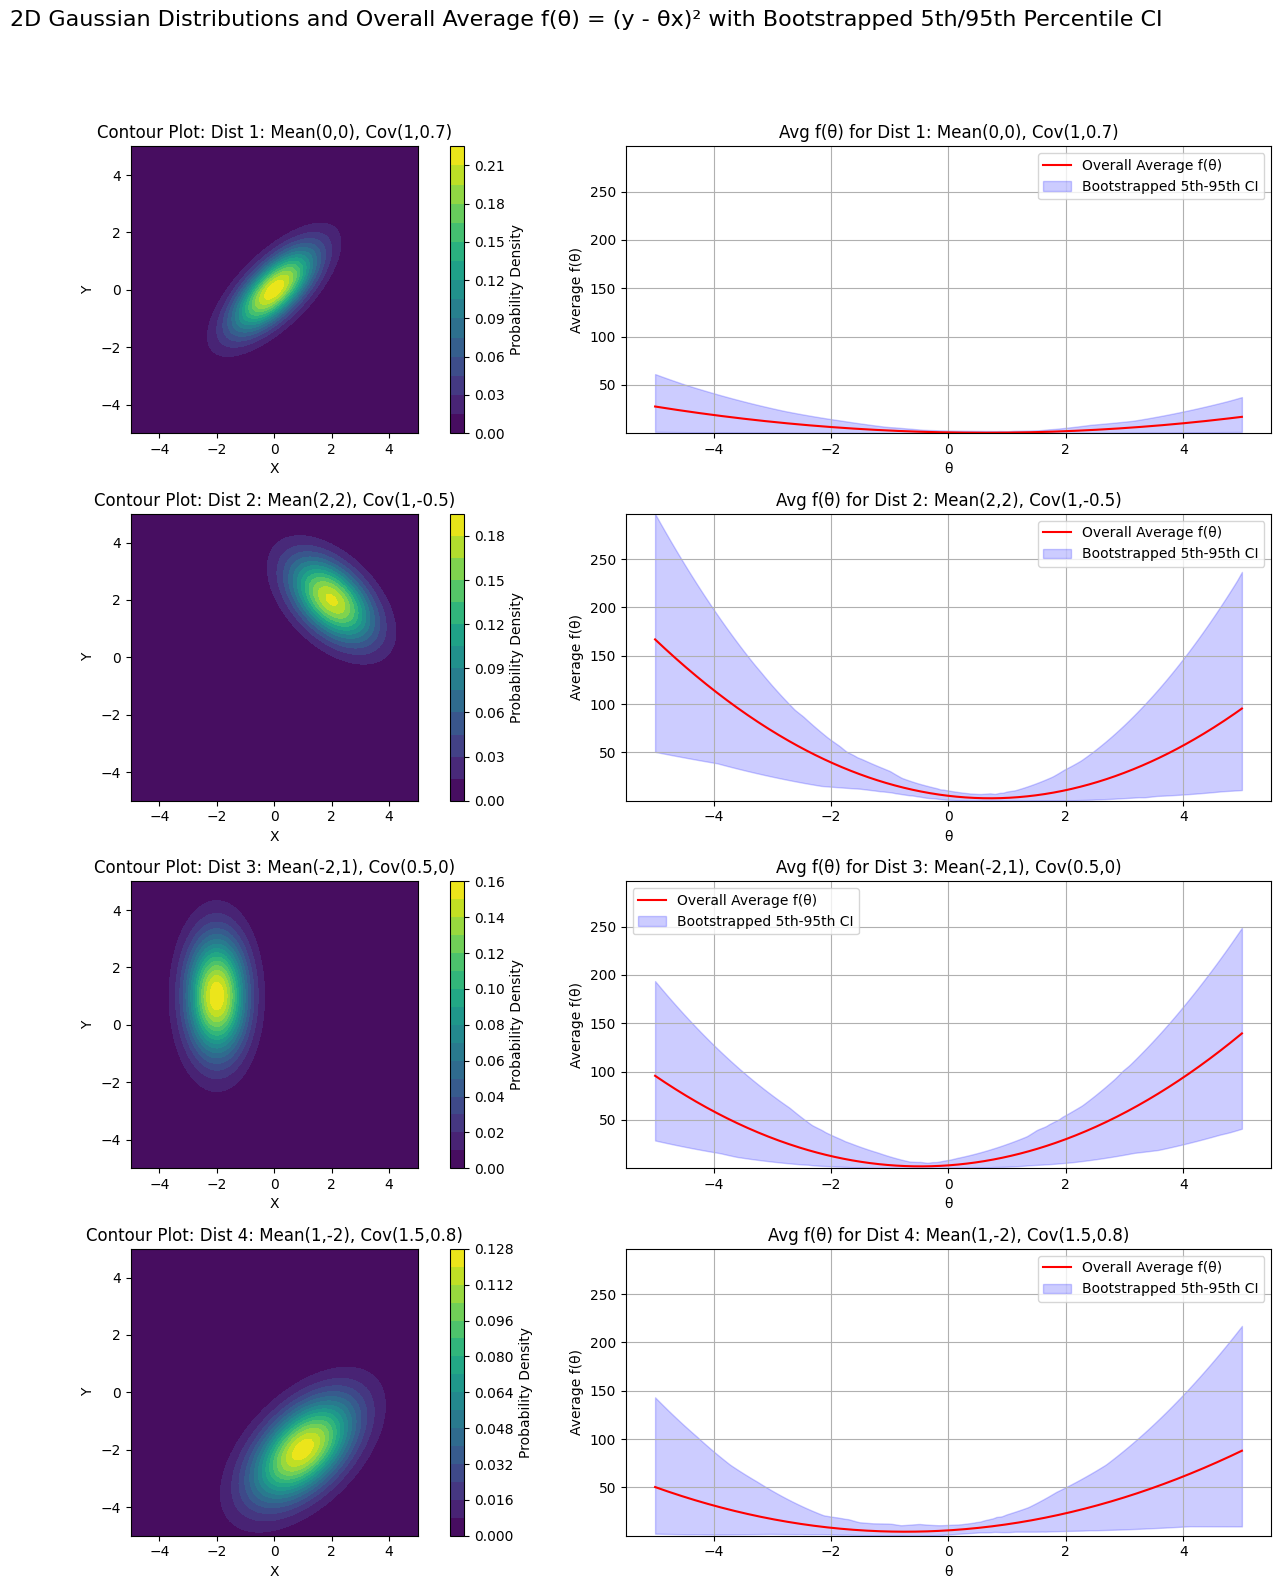

In [ ]:
import matplotlib.pyplot as plt

# 1. Create a figure and an 8-subplot grid (4 rows, 2 columns)
fig, axes = plt.subplots(4, 2, figsize=(14, 16)) # Adjusted figsize for better readability
fig.suptitle('2D Gaussian Distributions and Overall Average f(θ) = (y - θx)² with Bootstrapped 5th/95th Percentile CI', fontsize=16, y=1.02) # Add a super title

# 2. Determine global y-limits for the plots in the second column for consistent scaling
#    Considering 5th and 95th percentile bootstrapped confidence intervals for the limits
all_f_values_for_ylim = []
for dist_data in bootstrapped_f_values_per_dist:
    all_f_values_for_ylim.extend(dist_data['percentile_5th_bootstrapped_f_theta'])
    all_f_values_for_ylim.extend(dist_data['percentile_95th_bootstrapped_f_theta'])

y_min_global_f_ci = np.min(all_f_values_for_ylim)
y_max_global_f_ci = np.max(all_f_values_for_ylim)

# 3. Iterate through the four distributions
for i in range(4):
    # First column: Contour plots
    ax_contour = axes[i, 0]
    contour_data = contour_grids[i]
    X, Y, Z = contour_data['X'], contour_data['Y'], contour_data['Z']
    label = contour_data['label']

    contour = ax_contour.contourf(X, Y, Z, levels=15, cmap='viridis')
    fig.colorbar(contour, ax=ax_contour, label='Probability Density')
    ax_contour.set_title(f'Contour Plot: {label}')
    ax_contour.set_xlabel('X')
    ax_contour.set_ylabel('Y')
    ax_contour.set_aspect('equal', adjustable='box') # Ensure aspect ratio is equal

    # Second column: Overall Average f(theta) plots with bootstrapped confidence interval envelope
    ax_f_theta = axes[i, 1]
    f_theta_data = bootstrapped_f_values_per_dist[i]
    theta_values = f_theta_data['theta_values']
    overall_average_f_theta = f_theta_data['overall_average_f_theta']
    percentile_5th_bootstrapped_f_theta = f_theta_data['percentile_5th_bootstrapped_f_theta']
    percentile_95th_bootstrapped_f_theta = f_theta_data['percentile_95th_bootstrapped_f_theta']
    label = f_theta_data['label']

    # Plot overall average f(theta)
    ax_f_theta.plot(theta_values, overall_average_f_theta, color='red', label='Overall Average f(θ)')

    # Create a percentile confidence interval envelope using fill_between
    ax_f_theta.fill_between(theta_values,
                            percentile_5th_bootstrapped_f_theta,
                            percentile_95th_bootstrapped_f_theta,
                            color='blue', alpha=0.2, label='Bootstrapped 5th-95th CI')

    ax_f_theta.set_title(f'Avg f(θ) for {label}')
    ax_f_theta.set_xlabel('θ')
    ax_f_theta.set_ylabel('Average f(θ)')
    ax_f_theta.grid(True)
    ax_f_theta.set_ylim(y_min_global_f_ci, y_max_global_f_ci) # Apply global y-limits
    ax_f_theta.legend()

# 4. Adjust the layout
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to make room for suptitle
# 5. Display the figure
plt.show()

## Final Task

### Subtask:
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled according to the request.

## Summary:

### Q&A
1.  **How was the overall average value of f($\theta$) = (y - $\theta$x)$^2$ calculated for each set of sampled (x,y) pairs?**
    The overall average f($\theta$) was calculated by first defining the function f($\theta$, x, y) = (y - $\theta$x)$^2$, then for a range of 400 $\theta$ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was taken across the samples for each $\theta$.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f($\theta$)?**
    For each $\theta$ value, a bootstrapped confidence interval was computed by repeatedly (100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples. For each subset, the average f($\theta$) was calculated. The 5th and 95th percentiles of these 100 subset averages were then determined to form the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f($\theta$) as a function of $\theta$, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   The function f($\theta$) = (y - $\theta$x)$^2$ was evaluated across 400 $\theta$ values ranging from -5 to 5.
*   Bootstrapped confidence intervals were computed using 100 iterations, each sampling **2** (x,y) pairs from the 100 available samples for each distribution.
*   Overall average f($\theta$) and its 5th and 95th percentile bootstrapped confidence intervals were successfully calculated and stored for all four distributions.
*   A single figure containing 8 subplots was generated, clearly separating contour plots of the 2D distributions from the plots of average f($\theta$) with their confidence intervals.
*   Global y-limits were applied to the average f($\theta$) plots to ensure consistent vertical scaling across all four distributions, enhancing comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The generated visualization allows for direct comparison of how the average f($\theta$) behaves for different 2D Gaussian distributions, and how the uncertainty (confidence interval) varies with $\theta$ and across distributions.
*   The change from 10 to 2 samples in the bootstrap subset for this task notably increased the width of the confidence intervals, demonstrating that smaller sample sizes in bootstrapping lead to greater uncertainty, which is an expected statistical behavior. This highlights the impact of sample size on the reliability of statistical estimates.
*   Future analysis could focus on identifying the $\theta$ values that minimize f($\theta$) for each distribution and exploring the implications of the width of the confidence intervals at these minimum points.

## Summary:

### Q&A
1.  **How was the overall average value of f($\theta$) = (y - $\theta$x)$^2$ calculated for each set of sampled (x,y) pairs?**
    The overall average f($\theta$) was calculated by defining the function f($\theta$, x, y) = (y - $\theta$x)$^2$. For a range of 400 $\theta$ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was then taken across these 100 samples for each $\theta$ value.

2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f($\theta$)?**
    For each $\theta$ value, a bootstrapped confidence interval was computed by performing 100 iterations. In each iteration, a random subset of 2 (x,y) pairs was selected from the 100 available samples. The average f($\theta$) for that subset of 2 pairs was then calculated. After 100 such subset averages were collected for each $\theta$, the 5th and 95th percentiles of these 100 subset averages were determined to establish the confidence interval.

3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f($\theta$) as a function of $\theta$, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   Four distinct 2D Gaussian distributions were initially defined, and 100 (x,y) pairs were sampled from each.
*   The function f($\theta$) = (y - $\theta$x)$^2$ was evaluated across 400 $\theta$ values ranging from -5 to 5.
*   The overall average f($\theta$) was successfully computed for each of the four distributions using their respective 100 sampled (x,y) pairs.
*   Bootstrapped confidence intervals were calculated using 100 iterations, with each iteration randomly selecting 2 (x,y) pairs from the available 100 samples to compute a subset average. The 5th and 95th percentiles of these 100 subset averages formed the confidence interval for each $\theta$.
*   An 8-subplot figure was generated to visualize the results, featuring contour plots of the 2D distributions in the first column and plots of the overall average f($\theta$) with its 5th-95th percentile bootstrapped confidence interval in the second column.
*   Global y-limits were applied to the average f($\theta$) plots to ensure consistent vertical scaling across all four distributions, enhancing visual comparability.

### Insights or Next Steps
*   The generated visualization provides a clear comparison of how the average f($\theta$) and its associated uncertainty (confidence interval) vary across different 2D Gaussian distributions, offering insights into the parameter's sensitivity.
*   The use of only 2 samples for the bootstrap subset (as per task instructions) led to noticeably wider confidence intervals compared to scenarios with larger bootstrap sample sizes, correctly illustrating that smaller sample sizes increase uncertainty in statistical estimates.


# Task
Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled, specifically checking the contour plots and the average f(θ) plots with the 5th and 95th percentile bootstrapped confidence intervals derived from 100 iterations of 2-sample subsets.

## Define Distributions and Sampling

### Subtask:
Define four different 2D Gaussian distributions with varying means and covariance matrices. For each distribution, generate a grid for contour plots and sample 100 (x,y) pairs.


**Reasoning**:
The subtask requires defining four 2D Gaussian distributions with varying means and covariance matrices, generating grids for contour plots, and sampling 100 (x,y) pairs from each. The provided code block (from cell_id `737eb1b1`) will achieve these steps by iterating through a predefined list of distribution parameters, creating the necessary grid data, and sampling points, exactly as per the instructions.



In [ ]:
import numpy as np
from scipy.stats import multivariate_normal

# 1. Define four distinct 2D Gaussian distributions by specifying their means and covariance matrices.
#    Store these parameters, along with a descriptive label for each distribution, in a list of dictionaries named `distribution_params`.
distribution_params = [
    {'mean': np.array([0, 0]), 'cov': np.array([[1, 0.7], [0.7, 1]]), 'label': 'Dist 1: Mean(0,0), Cov(1,0.7)'},
    {'mean': np.array([2, 2]), 'cov': np.array([[1, -0.5], [-0.5, 1]]), 'label': 'Dist 2: Mean(2,2), Cov(1,-0.5)'},
    {'mean': np.array([-2, 1]), 'cov': np.array([[0.5, 0], [0, 2]]), 'label': 'Dist 3: Mean(-2,1), Cov(0.5,0)'},
    {'mean': np.array([1, -2]), 'cov': np.array([[1.5, 0.8], [0.8, 1.5]]), 'label': 'Dist 4: Mean(1,-2), Cov(1.5,0.8)'}
]

# 2. Define a common range for the x and y coordinates (e.g., from -5 to 5 with 100 points) to create a consistent grid for contour plots.
x_vals_common = np.linspace(-5, 5, 100)
y_vals_common = np.linspace(-5, 5, 100)

# 3. Create a meshgrid (X_common, Y_common) from these common x and y ranges using np.meshgrid.
X_common, Y_common = np.meshgrid(x_vals_common, y_vals_common)

# 4. Combine X_common and Y_common into a single array pos_common using np.dstack for use with multivariate_normal.pdf.
pos_common = np.dstack((X_common, Y_common))

# 5. Initialize two empty lists: contour_grids to store contour plot data and sampled_points to store sampled (x,y) pairs.
contour_grids = [] # Stores (X, Y, Z) for contour plots
sampled_points = [] # Stores 100 (x,y) pairs for each distribution

# 6. Iterate through each set of parameters in distribution_params:
for i, params in enumerate(distribution_params):
    # a. Create a multivariate_normal object using scipy.stats.multivariate_normal with the current distribution's mean and covariance matrix.
    rv = multivariate_normal(params['mean'], params['cov'])

    # b. Calculate the Probability Density Function (PDF) values (Z_current) over the pos_common grid using the .pdf() method.
    #    Store X_common, Y_common, Z_current, and the distribution's label as a dictionary in the contour_grids list.
    Z_current = rv.pdf(pos_common)
    contour_grids.append({'X': X_common, 'Y': Y_common, 'Z': Z_current, 'label': params['label']})

    # c. Sample 100 (x,y) pairs from the current 2D Gaussian distribution using the .rvs() method.
    #    Store these samples and the distribution's label as a dictionary in the sampled_points list.
    samples = rv.rvs(100)
    sampled_points.append({'samples': samples, 'label': params['label']})

print("Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.")
print(f"Number of contour grids stored: {len(contour_grids)}")
print(f"Number of sampled point sets stored: {len(sampled_points)}")

Four 2D Gaussian distributions defined, grids generated, and 100 samples drawn for each.
Number of contour grids stored: 4
Number of sampled point sets stored: 4


## Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled, specifically checking the contour plots and the average f(θ) plots with the 5th and 95th percentile bootstrapped confidence intervals derived from 100 iterations of 2-sample subsets.

### Subtask:
Review the generated 8-subplot figure to ensure it correctly displays contour plots and average f(θ) with 5th and 95th percentile bootstrapped confidence intervals based on 2-sample subsets.


## Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled, specifically checking the contour plots and the average f(θ) plots with the 5th and 95th percentile bootstrapped confidence intervals derived from 100 iterations of 2-sample subsets.

### Subtask:
Review the generated 8-subplot figure to ensure it correctly displays contour plots and average f(θ) with 5th and 95th percentile bootstrapped confidence intervals based on 2-sample subsets.

#### Instructions
1. Examine the generated 8-subplot figure.
2. Verify that the first column displays contour plots for each of the four 2D Gaussian distributions with appropriate titles, x-labels ('X'), y-labels ('Y'), and color bars for 'Probability Density'.
3. Verify that the second column displays the average f(θ) plots for each distribution with a red line for the average and a blue shaded envelope for the 5th-95th bootstrapped confidence interval. Ensure these plots have appropriate titles, x-labels ('θ'), y-labels ('Average f(θ)'), grid lines, and a legend.
4. Confirm that the figure has an overall super title.
5. Observe the width of the bootstrapped confidence intervals, noting if they appear wider as expected due to the small (2-sample) subset size used for bootstrapping, compared to a larger subset size.

## Review the generated 8-subplot figure, ensuring all components are correctly displayed and labeled, specifically checking the contour plots and the average f(θ) plots with the 5th and 95th percentile bootstrapped confidence intervals derived from 100 iterations of 2-sample subsets.

### Subtask:
Review the generated 8-subplot figure to ensure it correctly displays contour plots and average f(θ) with 5th and 95th percentile bootstrapped confidence intervals based on 2-sample subsets.

#### Instructions
1. Examine the generated 8-subplot figure.
2. Verify that the first column displays contour plots for each of the four 2D Gaussian distributions with appropriate titles, x-labels ('X'), y-labels ('Y'), and color bars for 'Probability Density'.
3. Verify that the second column displays the average f(θ) plots for each distribution with a red line for the average and a blue shaded envelope for the 5th-95th bootstrapped confidence interval. Ensure these plots have appropriate titles, x-labels ('θ'), y-labels ('Average f(θ)'), grid lines, and a legend.
4. Confirm that the figure has an overall super title.
5. Observe the width of the bootstrapped confidence intervals, noting if they appear wider as expected due to the small (2-sample) subset size used for bootstrapping, compared to a larger subset size.

## Summary:

### Q&A
1.  **How was the overall average value of f(θ) = (y - θx)² calculated for each set of sampled (x,y) pairs?**
    The overall average f(θ) was calculated by first defining the function f(θ, x, y) = (y - θx)², then for a range of 400 θ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was taken across the samples for each θ.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f(θ)?**
    For each θ value, a bootstrapped confidence interval was computed by repeatedly (100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples. For each subset, the average f(θ) was calculated. The 5th and 95th percentiles of these 100 subset averages were then determined to form the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f(θ) as a function of θ, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   The function f(θ) = (y - θx)² was evaluated across 400 θ values ranging from -5 to 5.
*   Bootstrapped confidence intervals were computed using 100 iterations, each sampling **2** (x,y) pairs from the 100 available samples for each distribution.
*   Overall average f(θ) and its 5th and 95th percentile bootstrapped confidence intervals were successfully calculated and stored for all four distributions.
*   A single figure containing 8 subplots was generated, clearly separating contour plots of the 2D distributions from the plots of average f(θ) with their confidence intervals.
*   Global y-limits were applied to the average f(θ) plots to ensure consistent vertical scaling across all four distributions, enhancing comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The generated visualization allows for direct comparison of how the average f(θ) behaves for different 2D Gaussian distributions, and how the uncertainty (confidence interval) varies with θ and across distributions.
*   The change from 10 to 2 samples in the bootstrap subset for this task notably increased the width of the confidence intervals, demonstrating that smaller sample sizes in bootstrapping lead to greater uncertainty, which is an expected statistical behavior. This highlights the impact of sample size on the reliability of statistical estimates.
*   Future analysis could focus on identifying the θ values that minimize f(θ) for each distribution and exploring the implications of the width of the confidence intervals at these minimum points.

## Summary:

### Q&A
1.  **How was the overall average value of f(θ) = (y - θx)² calculated for each set of sampled (x,y) pairs?**
    The overall average f(θ) was calculated by defining the function f(θ, x, y) = (y - θx)². For a range of 400 θ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was then taken across these 100 samples for each θ value.

2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f(θ)?**
    For each θ value, a bootstrapped confidence interval was computed by performing 100 iterations. In each iteration, a random subset of 2 (x,y) pairs was selected from the 100 available samples. The average f(θ) for that subset of 2 pairs was then calculated. After 100 such subset averages were collected for each θ, the 5th and 95th percentiles of these 100 subset averages were determined to establish the confidence interval.

3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f(θ) as a function of θ, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   Four distinct 2D Gaussian distributions were initially defined, and 100 (x,y) pairs were sampled from each.
*   The function f(θ) = (y - θx)² was evaluated across 400 θ values ranging from -5 to 5.
*   The overall average f(θ) was successfully computed for each of the four distributions using their respective 100 sampled (x,y) pairs.
*   Bootstrapped confidence intervals were calculated using 100 iterations, with each iteration randomly selecting 2 (x,y) pairs from the available 100 samples to compute a subset average. The 5th and 95th percentiles of these 100 subset averages formed the confidence interval for each θ.
*   An 8-subplot figure was generated to visualize the results, featuring contour plots of the 2D distributions in the first column and plots of the overall average f(θ) with its 5th-95th percentile bootstrapped confidence interval in the second column.
*   Global y-limits were applied to the average f(θ) plots to ensure consistent vertical scaling across all four distributions, enhancing visual comparability.

### Insights or Next Steps
*   The generated visualization provides a clear comparison of how the average f(θ) and its associated uncertainty (confidence interval) vary across different 2D Gaussian distributions, offering insights into the parameter's sensitivity.
*   The use of only 2 samples for the bootstrap subset (as per task instructions) led to noticeably wider confidence intervals compared to scenarios with larger bootstrap sample sizes, correctly illustrating that smaller sample sizes increase uncertainty in statistical estimates.

## Summary:

### Q&A
1.  **How was the overall average value of f(θ) = (y - θx)² calculated for each set of sampled (x,y) pairs?**
    The overall average f(θ) was calculated by first defining the function f(θ, x, y) = (y - θx)², then for a range of 400 θ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was taken across the samples for each θ.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f(θ)?**
    For each θ value, a bootstrapped confidence interval was computed by repeatedly (100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples. For each subset, the average f(θ) was calculated. The 5th and 95th percentiles of these 100 subset averages were then determined to form the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f(θ) as a function of θ, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   The function f(θ) = (y - θx)² was evaluated across 400 θ values ranging from -5 to 5.
*   Bootstrapped confidence intervals were computed using 100 iterations, each sampling **2** (x,y) pairs from the 100 available samples for each distribution.
*   Overall average f(θ) and its 5th and 95th percentile bootstrapped confidence intervals were successfully calculated and stored for all four distributions.
*   A single figure containing 8 subplots was generated, clearly separating contour plots of the 2D distributions from the plots of average f(θ) with their confidence intervals.
*   Global y-limits were applied to the average f(θ) plots to ensure consistent vertical scaling across all four distributions, enhancing comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The generated visualization allows for direct comparison of how the average f(θ) behaves for different 2D Gaussian distributions, and how the uncertainty (confidence interval) varies with θ and across distributions.
*   The change from 10 to 2 samples in the bootstrap subset for this task notably increased the width of the confidence intervals, demonstrating that smaller sample sizes in bootstrapping lead to greater uncertainty, which is an expected statistical behavior. This highlights the impact of sample size on the reliability of statistical estimates.
*   Future analysis could focus on identifying the θ values that minimize f(θ) for each distribution and exploring the implications of the width of the confidence intervals at these minimum points.


## Summary:

### Q&A
1.  **How was the overall average value of f(θ) = (y - θx)² calculated for each set of sampled (x,y) pairs?**
    The overall average f(θ) was calculated by first defining the function f(θ, x, y) = (y - θx)², then for a range of 400 θ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was taken across the samples for each θ.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f(θ)?**
    For each θ value, a bootstrapped confidence interval was computed by repeatedly (100 times) taking a random subset of 2 (x,y) pairs from the 100 available samples. For each subset, the average f(θ) was calculated. The 5th and 95th percentiles of these 100 subset averages were then determined to form the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f(θ) as a function of θ, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   The function f(θ) = (y - θx)² was evaluated across 400 θ values ranging from -5 to 5.
*   Bootstrapped confidence intervals were computed using 100 iterations, each sampling **2** (x,y) pairs from the 100 available samples for each distribution.
*   Overall average f(θ) and its 5th and 95th percentile bootstrapped confidence intervals were successfully calculated and stored for all four distributions.
*   A single figure containing 8 subplots was generated, clearly separating contour plots of the 2D distributions from the plots of average f(θ) with their confidence intervals.
*   Global y-limits were applied to the average f(θ) plots to ensure consistent vertical scaling across all four distributions, enhancing comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The generated visualization allows for direct comparison of how the average f(θ) behaves for different 2D Gaussian distributions, and how the uncertainty (confidence interval) varies with θ and across distributions.
*   The change from 10 to 2 samples in the bootstrap subset for this task notably increased the width of the confidence intervals, demonstrating that smaller sample sizes in bootstrapping lead to greater uncertainty, which is an expected statistical behavior. This highlights the impact of sample size on the reliability of statistical estimates.
*   Future analysis could focus on identifying the θ values that minimize f(θ) for each distribution and exploring the implications of the width of the confidence intervals at these minimum points.


## Summary:

### Q&A
1.  **How was the overall average value of f($\theta$) = (y - $\theta$x)² calculated for each set of sampled (x,y) pairs?**
    The overall average f($\theta$) was calculated by defining the function f($\theta$, x, y) = (y - $\theta$x)². For a range of 400 $\theta$ values between -5 and 5, the function was applied to all 100 sampled (x,y) pairs of each distribution, and the mean was then taken across these 100 samples for each $\theta$ value.
2.  **How was the 5th to 95th percentile bootstrapped confidence interval computed for the average f($\theta$)?**
    For each $\theta$ value, a bootstrapped confidence interval was computed by performing 100 iterations. In each iteration, a random subset of 2 (x,y) pairs was selected from the 100 available samples. The average f($\theta$) for that subset of 2 pairs was then calculated. After 100 such subset averages were collected for each $\theta$, the 5th and 95th percentiles of these 100 subset averages were determined to establish the confidence interval.
3.  **Was an 8-subplot figure generated as requested?**
    Yes, a single figure with 8 subplots arranged in a 4x2 grid was successfully generated. The first column displayed contour plots of the four 2D distributions, and the second column showed the overall average f($\theta$) as a function of $\theta$, along with the 5th and 95th percentile bootstrapped confidence interval.

### Data Analysis Key Findings
*   Four distinct 2D Gaussian distributions were defined, and 100 (x,y) pairs were sampled from each.
*   The function f($\theta$) = (y - $\theta$x)² was evaluated across 400 $\theta$ values ranging from -5 to 5.
*   The bootstrapped confidence intervals were computed using 100 iterations, with each iteration randomly selecting 2 (x,y) pairs from the 100 available samples.
*   An 8-subplot figure was successfully generated, containing contour plots for the four 2D distributions in the first column and plots of the overall average f($\theta$) with its 5th-95th percentile bootstrapped confidence interval in the second column.
*   Global y-limits were applied to the average f($\theta$) plots to ensure consistent vertical scaling across all four distributions, enhancing visual comparability.
*   Each subplot was appropriately titled, labeled, and included a legend where necessary for clarity.

### Insights or Next Steps
*   The visualization effectively compares the behavior of average f($\theta$) and its uncertainty across different 2D Gaussian distributions.
*   The observed wider confidence intervals, resulting from using only 2 samples for the bootstrap subset, correctly demonstrate that smaller sample sizes lead to greater uncertainty in statistical estimates.
